# Lighter vault of vaults - rebalancing method trials

Based on: `scratchpad/hyperliquid-waterfall-rc/04-backtest-rebalancing-method-trials.ipynb` (re-pointed to the Lighter public-pool universe)

## Hypothesis

The young Lighter (ZK-rollup perps DEX) public-pool universe may favour a different selection, weighting, or allocation method than the age-ramp capped waterfall baseline. This trial holds the universe, dates, capital, hard eligibility criteria, execution thresholds, and liquidity model fixed while applying all 31 methods catalogued in `scratchpad/vault-of-vaults/rebalanching-trials.md`.

## Experiment controls

- The exact notebook 03 strategy run is retained as the NB158 baseline.
- Full-period metrics cover 2025-08-01 through 2026-07-09.
- The primary comparison is the 120-return clean extension holdout from 2026-03-12 through 2026-07-09.
- Historical optimiser constants overlap the earlier part of the full period and are labelled accordingly.
- The outer vault address list comes from a current cached curator snapshot, so this experiment inherits static-membership survivorship bias even though age, TVL, price availability, and signals are evaluated by timestamp.

## Notes

Every row is reimplemented and backtested against the same Lighter trading universe, dates, capital, eligibility filters, liquidity model, and execution thresholds carried over from the Hyperliquid trial notebook. This is not a comparison of saved metrics from the historical notebooks; their identifiers and fixed method settings are used to define the trial rows below. Any method whose historical source did not provide one canonical setting is marked `approximation` in the performance table.

## Rebalancing methods compared

All methods use the shared universe, daily cycle, eligibility floors, 25,000 USD initial capital, liquidity model, and trade thresholds. Parameters below identify the method-specific signal and allocation mechanics; `redemption-aware` is the default portfolio target unless stated otherwise.

| ID | Name | Parameters | Description |
|---|---|---|---|
| NB22 | Inverse-volatility weighting | `1 / volatility(60d)`; `non_recycle`; redemption-aware target | It favours vaults with lower trailing 60-day volatility. It deploys its weights without recycling unused capacity. It keeps the common universe filters, liquidity caps, and daily rebalance controls fixed. |
| NB23a | Equal weight | `equal weight`; `non_recycle`; redemption-aware target | It gives every selected vault the same raw weight. It does not recycle capacity left unused after risk caps. It is the simple allocation control for the trial. |
| NB23b | Log-signal weighting | `log1p(age ramp)`; `recycle`; redemption-aware target | It compresses the age-ramp signal with a logarithm. It recycles unused capacity across selected vaults. It tests whether reducing signal dispersion improves deployment. |
| NB24 | Signal-ranked waterfall | `log1p(age ramp)`; `waterfall`; redemption-aware target | It ranks vaults using the log-compressed age-ramp signal. It deploys capital greedily down that ranking with waterfall sizing. It tests the historical signal-ranked allocator on the fixed universe. |
| NB26 | Sortino-based weighting | `positive Sortino(60d)`; `recycle`; redemption-aware target | It sizes vaults by positive trailing 60-day Sortino ratio. It recycles capacity from constrained vaults to other selected names. It emphasises downside-adjusted rather than total volatility-adjusted returns. |
| NB27 | Sharpe-based weighting | `positive Sharpe(60d)`; `recycle`; redemption-aware target | It sizes vaults by positive trailing 60-day Sharpe ratio. It recycles capacity after liquidity and concentration caps. It tests whether total-risk-adjusted performance is a useful direct weight. |
| NB28 | Diversified waterfall | `age ramp`; `diversified_waterfall`; protocol cap `40%` | It uses the structural age-ramp signal. It applies waterfall allocation with protocol concentration controls. The chain cap is non-binding because every pool is on Lighter. |
| NB29 | Dynamic diversified waterfall | `Sharpe(60d)`; `diversified_waterfall`; protocol cap `40%` | It re-ranks vaults daily by trailing 60-day Sharpe. It applies diversified waterfall allocation to that changing ranking. The chain cap is non-binding on this single-venue Lighter universe. |
| NB45 | Calmar-signal allocation | `positive Calmar(60d)`; `recycle`; redemption-aware target | It sizes vaults by positive trailing 60-day Calmar ratio. It recycles capacity across names that can accept it. It favours return per unit of historical drawdown. |
| NB54 | PSR concentration | `Calmar(60d)`; `PSR(60d)`; multiplier `0.50` | It uses Calmar as the primary signal. It scales maximum concentration by probabilistic Sharpe ratio confidence. It tests a continuous confidence-aware concentration limit. |
| NB59 | Linear PSR gate | `PSR(60d)` floor `0.30`; multiplier `0.50`; `psr_linear` | It excludes vaults below the fixed probabilistic Sharpe ratio floor. It scales surviving allocations linearly by their confidence. It tests a soft confidence gate rather than a binary ranking alone. |
| NB60 | Bayesian credibility weighting | `Sterling(180d)`; Bayesian half-life `60d`; `recycle` | It shrinks the Sterling signal towards the same-day cross-sectional prior. The shrinkage declines as a vault gains history. It tests whether young vault signals need credibility adjustment. |
| NB63 | Softmax allocation | `Sharpe(60d)`; softmax temperature `1.0`; `recycle` | It standardises trailing Sharpe values before applying softmax sizing. It uses the fixed temperature of one. It is an explicitly labelled approximation because the source did not expose one canonical temperature. |
| NB64 | Threshold-linear allocation | `Sharpe rank`; thresholds `25%` and `75%`; `recycle` | It maps cross-sectional Sharpe ranks through a clipped linear rule. The lower and upper thresholds are the 25th and 75th percentiles. It is an explicitly labelled approximation of the historical method. |
| NB66 | Dual-signal gate and weight | `Bayesian gate`; `Sharpe(60d)` weights; `recycle` | It gates candidates using Bayesian credibility. It sizes gated survivors using trailing Sharpe. It separates the selection signal from the sizing signal. |
| NB68 | Bayesian gate with equal weight | `Bayesian gate`; equal weights; `recycle` | It uses the same Bayesian gate as NB66. It gives every gated survivor equal raw weight. It is the clean weighting ablation for the NB66 gate. |
| NB71 | Rank-composite selection | `return, Sharpe, Calmar(60d), age, TVL` ranks; equal weights | It averages five same-day cross-sectional percentile ranks. It selects the highest composite ranks and equal-weights them. It tests a broad multi-feature selector rather than one signal. |
| NB88 | Age-ramp weighting | `age ramp`; `recycle`; redemption-aware target | It uses the notebook 03 age-ramp signal directly. It uses normal recycled allocation rather than waterfall sizing. It is the structural signal baseline without the release-candidate allocator. |
| NB93 | Age-TVL soft prior | `age ramp × TVL`; TVL soft floor `$15,000`; `recycle` | It multiplies the age-ramp signal by a clipped TVL factor. It retains the shared hard TVL eligibility floor. It tests whether a softer capacity preference improves the age signal. |
| NB101 | Age ramp with trend overlay | `age ramp 0.25y`; `trend R²(30d)`; strength `0.30` | It overlays trailing trend fit on the age-ramp signal. The overlay increases weights for stronger 30-day trends. It tests whether trend quality adds useful information to vault age. |
| NB102 | Age-bucket equal weight | age buckets `<90`, `90–270`, `≥270` days; equal cohorts | It separates eligible vaults into three age cohorts. It allocates equally across active cohorts and equally within each cohort. It tests whether age diversification matters more than continuous age weighting. |
| NB109 | Volatility-of-volatility penalty | `age ramp`; `vol-of-vol(60d)` penalty `0.30` | It starts from the age-ramp signal. It applies a soft penalty to unstable trailing volatility. It tests whether volatility stability improves the structural allocation. |
| NB116 | Sharpe-optimised age buckets | age buckets `<60`, `60–90`, `≥90` days; equal cohorts | It uses the fixed historical winning age-bucket boundaries. It equal-weights the active cohorts and their members. It does not re-optimise boundaries on this evaluation period. |
| NB128 | Correlation-cluster equal weight | correlation window `60d`; distance threshold `0.50`; cluster equal weight | It clusters trailing return correlations deterministically. It equal-weights clusters before equal-weighting their members. It falls back conservatively when history or cluster breadth is insufficient. |
| NB130 | Survivor-first renormalisation | `age ramp`; top 20 survivors; `survivor_non_recycle` | It selects the top age-ramp survivors before normalising. It does not recycle capacity after the survivor-first allocation. It isolates the cash-drag behaviour of this historical branch. |
| NB131 | Age-ramp selection with equal deployment | `age_select_equal`; top 20 survivors; `non_recycle` | It uses age ramp only to select survivors. It then assigns equal raw weights without recycling capacity. It isolates selection from signal-proportional deployment. |
| NB142 | Equal-weight recycle | `age_select_equal`; top 20 survivors; `recycle` | It uses age ramp only to select survivors. It equal-weights them and recycles unused capacity. It is the recycled equal-weight allocator control. |
| NB143 | Capped survivor-first waterfall | `age ramp`; `waterfall`; plain-equity target | It ranks survivors by age ramp and applies capped waterfall sizing. It targets plain current equity rather than redemption-aware investable equity. It isolates the pre-release-candidate cash-target policy. |
| NB144 | Capacity-aware equal weight | `sqrt(TVL)` tilt `[1, 2]`; `recycle`; equal selection | It starts from equal weights across selected vaults. It tilts those weights by a clipped square-root TVL capacity factor. It tests whether capacity-aware equal allocation improves deployment. |
| NB152 | Equal-weight recycle with minimum hold | `age_select_equal`; `minimum_hold_recycle`; hold `3d` | It uses equal-weight recycled allocation after age-based selection. It protects otherwise-eligible young positions from discretionary full exits for three days. It tests whether a brief holding period reduces churn. |
| NB158 | Waterfall release candidate | `age ramp`; `waterfall`; redemption-aware target | It ranks vaults with the age-ramp signal. It applies capped waterfall sizing to the redemption-aware portfolio target. It is the unchanged notebook 03 release-candidate baseline. |

## Universe notes

- Lighter pools are non-EVM: the off-chain feed publishes them under the synthetic chain id `9998` with
  synthetic `lighter-pool-{account_index}` addresses and a placeholder zero denomination-token address.
  The universe is restricted to USDC pools, which excludes Lighter's separate USDG Robinhood Chain deployment.
- The Lighter cohort is young and small (~34 USDC pools, most launched from August 2025), so early cycles
  admit few eligible pools and the clean-extension holdout is short. Treat all rankings as exploratory.

## Key new insights and what we learnt from this experiment

- All 31 catalogued methods completed on the 34-pool Lighter USDC universe, so the trial harness ports cleanly from Hyperliquid to Lighter.
- Risk-adjusted performance is far weaker than the Hyperliquid run. Every method's full-period Sharpe is at or below 1.18, and the best holdout Sharpe is 1.49 — versus 3.81 for the Hyperliquid release candidate. This is the expected consequence of a younger, thinner, uniformly `Severe`-risk pool set.
- The age-ramp capped waterfall baseline (NB158) is only mid-pack over the full period (0.72 Sharpe, 25.11% CAGR, -26.48% max drawdown) but is a co-leader on the clean extension holdout: 73.72% holdout CAGR and 1.48 holdout Sharpe, the highest holdout CAGR among the top-Sharpe methods. NB101 (age ramp with a 30-day trend overlay) edges it on holdout Sharpe (1.49) with a shallower -8.09% holdout drawdown but lower holdout CAGR (49.84%).
- Method ranking inverts relative to Hyperliquid. NB28 (Diversified waterfall) — the headline-CAGR winner on Hyperliquid — is the single worst method on Lighter (-15.88% full CAGR, -0.31 Sharpe). The direct risk-adjusted weighters (NB26 Sortino, NB27 Sharpe, NB45 Calmar) cluster at the bottom, while structural age-ramp selection/equal-weight allocators dominate the top of the holdout ranking.
- NB29 (Dynamic diversified waterfall) is the shallowest-drawdown credible method: best full-period Sharpe (1.18) at only -8.74% full drawdown and -5.85% holdout drawdown, consistent with its historically low deployment / high-cash profile rather than a return edge.

## Summary of results

Primary ranking is the clean extension holdout (2026-03-12 → 2026-07-09, 120 daily returns). `historical-overlap` provenance means the method's constants were tuned on data overlapping the earlier full period, so full-period scores are exploratory. NB63 and NB64 are `approximation` rows and are excluded from winner claims.

| Result | ID | Method | Holdout CAGR | Holdout Sharpe | Holdout max DD | Full Sharpe |
| --- | --- | --- | ---: | ---: | ---: | ---: |
| Best holdout Sharpe | NB101 | Age ramp with trend overlay | 49.84% | 1.49 | -8.09% | 0.92 |
| Co-leader, best holdout CAGR + retained baseline | NB158 | Waterfall release candidate | 73.72% | 1.48 | -11.76% | 0.72 |
| Shallowest drawdown, high cash | NB29 | Dynamic diversified waterfall | 22.69% | 1.32 | -5.85% | 1.18 |
| Best full-period CAGR | NB54 | PSR concentration | 38.83% | 0.97 | -11.57% | 0.99 |
| Worst method (flipped vs Hyperliquid) | NB28 | Diversified waterfall | -6.38% | -0.09 | -12.56% | -0.31 |

Over the full period (2025-08-01 → 2026-07-09) the retained NB158 baseline returns 25.11% CAGR, 0.72 Sharpe, and -26.48% maximum drawdown. Full-period CAGR spans -15.88% (NB28) to 41.82% (NB54), but no method clears a 1.2 full-period Sharpe.

## Robustness of results

- **The entire Lighter result is tail-driven.** Neutralising each method's largest 5% of strictly profitable daily returns to 0% (negatives preserved) turns every one of the 31 methods negative over the full period: NB158 falls from +25.11% to -35.85% CAGR (0.72 → -0.98 Sharpe, -26.48% → -44.39% drawdown), and NB101 from +31.42% to -22.42%. The least-fragile methods (NB22 inverse-volatility -11.97%, NB29 -15.13%) are still negative. No rebalancing method delivers broad-based, outlier-independent profit on this universe over the full period, so all rankings above are conditional on a handful of up-days.
- **Rolling stability is poor.** Trailing-90-day Sharpe minima are deeply negative for the leaders (-2.23 for the NB158/NB143/NB24 waterfall group, -1.69 for NB101), confirming long stretches of negative risk-adjusted return within the window.
- **Universe limitations.** 34 USDC pools, most launched from August 2025, all labelled `Severe` risk; the outer address list is a current cached curator snapshot, so the trial inherits static-membership survivorship bias even though age, TVL, price availability, and signals are evaluated point-in-time. The 120-return holdout makes annualised CAGR unstable.
- **Provenance.** Winning constants are `historical-overlap` (tuned on Hyperliquid-era overlapping data), not clean out-of-sample evidence for Lighter; NB63 and NB64 are declared approximations. The "NB158 current-data drift" line printed by the trial cell compares against the Hyperliquid notebook-03 stored metrics and is not a meaningful Lighter baseline.


# Trading universe and available pairs

Build the fixed Hyperliquid vault universe, supporting benchmark pairs, and point-in-time indicators shared by every trial. The table shows the available pairs used by the comparison.

In [1]:
import datetime
import logging
import re

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


In [2]:
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.lighter

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
# Lighter pools are USDC-denominated with a placeholder zero denomination-token
# address on the synthetic Lighter chain (9998); match the reserve to that so
# deposits need no cross-asset conversion.
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.lighter.value,
    address='0x0000000000000000000000000000000000000000',
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: Lighter
Reserve asset: <USDC at 0x0000000000000000000000000000000000000000>


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters
from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier for the Lighter rebalancing-method trials variant.
    id = '02-backtest-rebalancing-method-trials'

    #: Daily candles, matching the Hyperliquid trial the Lighter variant is based on.
    candle_time_bucket = TimeBucket.d1
    #: Daily rebalance cadence is the validated schedule used in NB143 and NB154-NB157.
    cycle_duration = CycleDuration.cycle_1d
    #: Lighter (synthetic chain 9998) is the primary chain for pools.
    chain_id = CHAIN_ID
    #: Lighter is the primary execution chain for these pools.
    primary_chain_id = CHAIN_ID
    #: Keep the same exchange set as NB143, NB153, and the live-style test strategy.
    exchanges = EXCHANGES

    #: NB141-NB157 validated the survivor-first allocator family with a 20-vault basket.
    #: Keep this fixed so NB158 is directly comparable to NB143 and the NB154-NB157 robustness reruns.
    max_assets_in_portfolio = 20
    #: NB143 and NB154-NB157 used 98% target deployment and the corrected waterfall branch held up there.
    #: NB156 showed lower allocation is viable, but not better enough to replace the release default.
    allocation_pct = 0.98
    #: The 12% cap is the survivor-first concentration limit carried through NB143-NB157.
    #: Keep it unchanged because the corrected waterfall case was validated with this exact cap.
    max_concentration_pct = 0.12
    #: NB156 showed tighter per-pool caps reduce both return and deployment.
    #: Keep the 20% pool-cap ceiling from NB143 so we do not reintroduce unnecessary cash drag.
    per_position_cap_of_pool_pct = 0.2
    #: Engine hygiene threshold used across the survivor-first notebooks.
    #: Keep it because the alpha model uses it when cleaning up tiny residual positions.
    min_portfolio_weight_pct = 0.005

    #: Keep the conservative 5 USD minimum deposit floor from the Hyperliquid trial.
    absolute_min_vault_deposit_usd = 5.0
    #: Preserve the old 50 USD buy threshold at 100k initial cash.
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    #: Preserve the old 10 USD sell threshold at 100k initial cash.
    sell_rebalance_min_threshold_of_initial_cash_pct = 0.0001

    #: NB141 selected this wider survivor-first TVL floor and NB143-NB157 validated the allocator on it.
    #: This is intentionally the survivor-first release setting, not the older NB124/NB126 production threshold.
    min_tvl_usd = 7_500
    #: NB141 also selected this young-vault-inclusive age floor for the survivor-first branch.
    #: Keep it fixed so NB158 stays comparable with the corrected waterfall validation chain.
    min_age = 0.075
    #: The corrected reruns kept `age_ramp` as the surviving signal family and NB154-NB157 validated waterfall on top of it.
    weight_signal = 'age_ramp'
    #: NB143 and the corrected robustness notebooks all used a 0.75-year ramp.
    #: Keep the signal definition unchanged so NB158 isolates the release-candidate packaging, not signal drift.
    age_ramp_period = 0.75

    #: August 2025 remains the canonical mature-universe start used by the release branch.
    backtest_start = datetime.datetime(2025, 8, 1)
    #: Exclusive end boundary; includes the completed daily cycle for yesterday, 2026-07-09.
    backtest_end = datetime.datetime(2026, 7, 10)
    #: Smaller bankroll for testing release-candidate behaviour at 25,000 USD initial capital.
    initial_cash = 25_000
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    sell_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * sell_rebalance_min_threshold_of_initial_cash_pct,
    )

    #: Default routing is still required by the strategy runtime even though it is not the alpha source.
    routing = TradeRouting.default
    #: Set deliberately high so live and notebook indicator calculations use effectively all available history.
    #: This is an operational correction to the old 120-day default because `age()` and other history-derived indicators
    #: depend on the first available data point and would be silently biased by a truncated lookback window.
    required_history_period = datetime.timedelta(days=365 * 20)
    #: Keep the same live-style slippage assumption as NB153 and `hyper-ai-test.py`.
    slippage_tolerance_pct = 0.0060
    #: Assume no liquidity if there is a gap in TVL data.
    assummed_liquidity_when_data_missings_usd = 0.01


parameters = StrategyParameters.from_class(Parameters)

In [4]:
from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_lighter_vault_universe

load_dotenv(override=True)


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    source_vaults = build_lighter_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


Preparing trading universe on chain Lighter


We have total 392022 pairs in dataset and going to use 3 pairs for the strategy
Lighter universe fingerprint: 000b4b3e
Loaded 34 cached Lighter vaults (lighter-tvl7500-topall-age0.0-sort1Y-cur000b4b3e)


Failed to parse vault entry: 4217 is not a valid ChainId


Failed to parse vault entry: 4217 is not a valid ChainId


Failed to parse vault entry: 4217 is not a valid ChainId


...

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:00<00:00, 23.31it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
274340006,Algorithmi,USDC,lighter,traded,NaN,0.00,2025-09-12 00:00:00,12 days 00:00:00,0.00,"12,939",12 days,- / -,None,None,-,20.0%,0.0%
277341188,Alleged Al,USDC,lighter,traded,NaN,0.00,2026-01-03 00:00:00,12 days 00:00:00,0.00,"502,108",12 days,- / -,None,None,-,25.0%,0.0%
270129608,BTC 3x lon,USDC,lighter,traded,NaN,0.00,2025-08-05 00:00:00,63 days 00:00:00,0.00,170,12 days,- / -,None,None,-,0.0%,0.0%
278414794,BTC 3x sho,USDC,lighter,traded,NaN,0.00,2025-08-05 00:00:00,49 days 00:00:00,0.00,"1,283",12 days,- / -,None,None,-,0.0%,0.0%
270571778,BTC vs ALT,USDC,lighter,traded,NaN,0.00,2025-10-08 00:00:00,12 days 00:00:00,0.00,"412,433",12 days,- / -,None,None,-,20.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
2991521,WETH,USDC,uniswap-v3,traded,0.05,,-,-,276144.50,"533,459",12 days,0.0% / 0.0%,None,None,-,NaN,NaN
284325574,Xiaohei,USDC,lighter,traded,NaN,0.00,2025-10-27 00:00:00,37 days 00:00:00,0.00,0,12 days,- / -,None,None,-,20.0%,0.0%
276067765,[ Systemic,USDC,lighter,traded,NaN,0.00,2026-03-05 00:00:00,12 days 00:00:00,0.00,"736,727",12 days,- / -,None,None,-,10.0%,0.0%
281531772,pmalt,USDC,lighter,traded,NaN,0.00,2026-05-07 00:00:00,12 days 00:00:00,0.00,"197,725",12 days,- / -,None,None,-,20.0%,0.0%
276225259,pool1,USDC,lighter,traded,NaN,,-,-,0.00,979,12 days,- / -,None,None,-,30.0%,0.0%


In [5]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators
from tradeexecutor.strategy.pandas_trader.indicator import calculate_and_load_indicators_inline

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define()
def age(close: pd.Series) -> pd.Series:
    inception = close.index[0]
    age_years = (close.index - inception) / pd.Timedelta(days=365.25)
    return pd.Series(age_years, index=close.index)


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(dependencies=(age,), source=IndicatorSource.dependencies_only_universe)
def age_inclusion_criteria(
    min_age: float,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(age)
    mask = series >= min_age
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
        age_inclusion_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    min_age: float,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)
    age_series = dependency_resolver.get_indicator_data(
        age_inclusion_criteria,
        parameters={'min_age': min_age},
    )

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
            'age_pair_ids': age_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = (
            set(row['tvl_pair_ids'])
            & set(row['trading_availability_pair_ids'])
            & set(row['age_pair_ids'])
        )
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


@indicators.define(dependencies=(age,), source=IndicatorSource.dependencies_only_per_pair)
def age_ramp_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    age_ramp_period: float = 1.0,
) -> pd.Series:
    vault_age = dependency_resolver.get_indicator_data('age', pair=pair)
    return (vault_age / age_ramp_period).clip(upper=1.0).clip(lower=0.05)


@indicators.define(dependencies=(inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def all_criteria_included_pair_count(
    min_tvl_usd: USDollarAmount,
    min_age: float,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
            "min_age": min_age,
        },
    )
    return series.apply(len)


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


@indicators.define(dependencies=(age_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def age_included_pair_count(
    min_age: float,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "age_inclusion_criteria",
        parameters={
            "min_age": min_age,
        },
    )
    return series.apply(len)


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_pair_count(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }
    series = strategy_universe.data_universe.candles.df["open"]
    swap_index = series.index.swaplevel(0, 1)

    seen_pairs = set()
    seen_data = {}
    for timestamp, pair_id in swap_index:
        if pair_id in benchmark_pair_ids:
            continue
        seen_pairs.add(pair_id)
        seen_data[timestamp] = len(seen_pairs)

    return pd.Series(seen_data.values(), index=list(seen_data.keys()))



@indicators.define()
def daily_return(close: pd.Series) -> pd.Series:
    """Daily vault share-price return using observations available up to each timestamp."""
    return close.resample('1D').last().pct_change(fill_method=None)


@indicators.define(dependencies=(daily_return,), source=IndicatorSource.dependencies_only_per_pair)
def rolling_return_60(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    returns = dependency_resolver.get_indicator_data('daily_return', pair=pair)
    return (1.0 + returns).rolling(60, min_periods=14).apply(lambda values: values.prod() - 1.0, raw=True)


@indicators.define(dependencies=(daily_return,), source=IndicatorSource.dependencies_only_per_pair)
def rolling_volatility_60(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    returns = dependency_resolver.get_indicator_data('daily_return', pair=pair)
    return returns.rolling(60, min_periods=14).std() * (365.0 ** 0.5)


@indicators.define(dependencies=(daily_return,), source=IndicatorSource.dependencies_only_per_pair)
def rolling_sharpe_60(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    returns = dependency_resolver.get_indicator_data('daily_return', pair=pair)
    mean = returns.rolling(60, min_periods=14).mean() * 365.0
    volatility = returns.rolling(60, min_periods=14).std() * (365.0 ** 0.5)
    return mean / volatility.replace(0.0, float('nan'))


@indicators.define(dependencies=(daily_return,), source=IndicatorSource.dependencies_only_per_pair)
def rolling_sortino_60(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    returns = dependency_resolver.get_indicator_data('daily_return', pair=pair)
    mean = returns.rolling(60, min_periods=14).mean() * 365.0
    downside = returns.clip(upper=0.0)
    downside_volatility = downside.rolling(60, min_periods=14).std() * (365.0 ** 0.5)
    return mean / downside_volatility.replace(0.0, float('nan'))


@indicators.define(dependencies=(daily_return,), source=IndicatorSource.dependencies_only_per_pair)
def rolling_calmar_60(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    returns = dependency_resolver.get_indicator_data('daily_return', pair=pair)

    def _calmar(values):
        values = pd.Series(values).dropna()
        if len(values) < 14:
            return float('nan')
        curve = (1.0 + values).cumprod()
        max_drawdown = abs((curve / curve.cummax() - 1.0).min())
        return values.mean() * 365.0 / max(max_drawdown, 0.01)

    return returns.rolling(60, min_periods=14).apply(_calmar, raw=False)


@indicators.define(dependencies=(daily_return,), source=IndicatorSource.dependencies_only_per_pair)
def rolling_psr_60(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    from scipy.stats import norm

    returns = dependency_resolver.get_indicator_data('daily_return', pair=pair)

    def _psr(values):
        values = pd.Series(values).dropna()
        n = len(values)
        if n < 14 or values.std() <= 0:
            return float('nan')
        sharpe = values.mean() / values.std()
        skew = values.skew()
        kurtosis = values.kurtosis() + 3.0
        denominator = max(1.0 - skew * sharpe + ((kurtosis - 1.0) / 4.0) * sharpe ** 2, 1e-12)
        statistic = sharpe * ((n - 1.0) / denominator) ** 0.5
        return float(norm.cdf(statistic))

    return returns.rolling(60, min_periods=14).apply(_psr, raw=False)


@indicators.define(dependencies=(daily_return,), source=IndicatorSource.dependencies_only_per_pair)
def sterling_signal_180(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    returns = dependency_resolver.get_indicator_data('daily_return', pair=pair)

    def _sterling(values):
        values = pd.Series(values).dropna()
        if len(values) < 14:
            return float('nan')
        curve = (1.0 + values).cumprod()
        max_drawdown = abs((curve / curve.cummax() - 1.0).min())
        ratio = values.mean() * 365.0 / (max_drawdown + 0.10)
        return float(pd.Series([max(ratio, 0.0)]).map(lambda value: __import__('math').log1p(value)).iloc[0])

    return returns.rolling(180, min_periods=14).apply(_sterling, raw=False)


@indicators.define()
def trend_r2_30(close: pd.Series) -> pd.Series:
    import numpy as np

    daily_close = close.resample('1D').last()

    def _r2(values):
        values = np.asarray(values, dtype=float)
        if len(values) < 14 or np.any(values <= 0) or not np.all(np.isfinite(values)):
            return float('nan')
        y = np.log(values)
        x = np.arange(len(y), dtype=float)
        slope, intercept = np.polyfit(x, y, 1)
        fitted = slope * x + intercept
        total = ((y - y.mean()) ** 2).sum()
        return float(1.0 - ((y - fitted) ** 2).sum() / total) if total > 0 else 0.0

    return daily_close.rolling(30, min_periods=14).apply(_r2, raw=True)


@indicators.define(dependencies=(daily_return,), source=IndicatorSource.dependencies_only_per_pair)
def volatility_of_volatility_60(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    returns = dependency_resolver.get_indicator_data('daily_return', pair=pair)
    realised_volatility = returns.rolling(14, min_periods=7).std() * (365.0 ** 0.5)
    return realised_volatility.rolling(60, min_periods=14).std()


@indicators.define(dependencies=(daily_return,), source=IndicatorSource.dependencies_only_universe)
def correlation_cluster_weights_60(
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    import numpy as np
    from collections import Counter
    from scipy.cluster.hierarchy import fcluster, linkage
    from scipy.spatial.distance import squareform

    all_returns = dependency_resolver.get_indicator_data_pairs_combined('daily_return')
    returns_df = all_returns.unstack(level='pair_id').sort_index()
    timestamps = []
    weight_dicts = []

    for index in range(60, len(returns_df)):
        timestamp = returns_df.index[index]
        window = returns_df.iloc[index - 60:index]
        valid_columns = window.columns[window.notna().sum() >= 14]
        if len(valid_columns) < 2:
            weights = {str(pair_id): 1.0 for pair_id in valid_columns}
        else:
            clean = window[valid_columns].fillna(0.0)
            correlation = clean.corr().fillna(0.0)
            np.fill_diagonal(correlation.values, 1.0)
            distance = (1.0 - correlation).clip(lower=0.0, upper=2.0)
            try:
                condensed = squareform(distance.values, checks=False)
                clusters = fcluster(linkage(condensed, method='average'), t=0.5, criterion='distance')
                counts = Counter(clusters)
                cluster_count = len(counts)
                weights = {
                    str(pair_id): 1.0 / (counts[cluster_id] * cluster_count)
                    for pair_id, cluster_id in zip(valid_columns, clusters)
                }
            except Exception:
                weights = {str(pair_id): 1.0 / len(valid_columns) for pair_id in valid_columns}
        timestamps.append(timestamp)
        weight_dicts.append(weights)

    return pd.Series(weight_dicts, index=pd.DatetimeIndex(timestamps), dtype=object)

indicator_data = calculate_and_load_indicators_inline(
    strategy_universe=strategy_universe,
    create_indicators=indicators.create_indicators,
    parameters=parameters,
)


Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-lighter_1d_37pe592cd75_2021-05-06-2026-07-10_ff_cross_de8d156ae


Calculating indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, age_ramp_weight, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count, daily_return, rolling_return_60, rolling_volatility_60, rolling_sharpe_60, rolling_sortino_60, rolling_calmar_60, rolling_psr_60, sterling_signal_180, trend_r2_30, volatility_of_volatility_60, correlation_cluster_weights_60 using 8 processes:   0%|          | 0/490 [00:00<?, ?it/s]

Calculating indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, age_ramp_weight, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count, daily_return, rolling_return_60, rolling_volatility_60, rolling_sharpe_60, rolling_sortino_60, rolling_calmar_60, rolling_psr_60, sterling_signal_180, trend_r2_30, volatility_of_volatility_60, correlation_cluster_weights_60 using 8 processes:   0%|          | 1/490 [00:13<1:47:17, 13.17s/it]

/var/folders/12/pbc59svn70q_9dfz1kjl3zww0000gn/T/ipykernel_86490/1290859460.py:37: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.


Calculating indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, age_ramp_weight, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count, daily_return, rolling_return_60, rolling_volatility_60, rolling_sharpe_60, rolling_sortino_60, rolling_calmar_60, rolling_psr_60, sterling_signal_180, trend_r2_30, volatility_of_volatility_60, correlation_cluster_weights_60 using 8 processes:   1%|          | 3/490 [00:15<36:09,  4.45s/it]  

...

Calculating indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, age_ramp_weight, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count, daily_return, rolling_return_60, rolling_volatility_60, rolling_sharpe_60, rolling_sortino_60, rolling_calmar_60, rolling_psr_60, sterling_signal_180, trend_r2_30, volatility_of_volatility_60, correlation_cluster_weights_60 using 8 processes, dependency group #3:   0%|          | 0/490 [00:00<?, ?it/s]

Calculating indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, age_ramp_weight, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count, daily_return, rolling_return_60, rolling_volatility_60, rolling_sharpe_60, rolling_sortino_60, rolling_calmar_60, rolling_psr_60, sterling_signal_180, trend_r2_30, volatility_of_volatility_60, correlation_cluster_weights_60 using 8 processes, dependency group #3:   1%|          | 3/490 [00:00<00:37, 12.87it/s]

Calculating indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, age_ramp_weight, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count, daily_return, rolling_return_60, rolling_volatility_60, rolling_sharpe_60, rolling_sortino_60, rolling_calmar_60, rolling_psr_60, sterling_signal_180, trend_r2_30, volatility_of_volatility_60, correlation_cluster_weights_60 using 8 processes, dependency group #3:   1%|          | 3/490 [00:00<00:37, 12.84it/s]

Calculating indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, age_ramp_weight, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count, daily_return, rolling_return_60, rolling_volatility_60, rolling_sharpe_60, rolling_sortino_60, rolling_calmar_60, rolling_psr_60, sterling_signal_180, trend_r2_30, volatility_of_volatility_60, correlation_cluster_weights_60 using 8 processes, dependency group #4:   0%|          | 0/490 [00:00<?, ?it/s]

Calculating indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, age_ramp_weight, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count, daily_return, rolling_return_60, rolling_volatility_60, rolling_sharpe_60, rolling_sortino_60, rolling_calmar_60, rolling_psr_60, sterling_signal_180, trend_r2_30, volatility_of_volatility_60, correlation_cluster_weights_60 using 8 processes, dependency group #4:   0%|          | 1/490 [00:00<00:10, 44.65it/s]

# Results

The unfiltered comparison runs the NB158 baseline and every reimplemented rebalance method on the shared notebook 03 universe. The equity chart normalises all curves to initial equity and uses a logarithmic scale so that every method remains visible.

In [6]:
from tradeexecutor.backtest.backtest_runner import run_backtest_inline
from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.statistics.key_metric import (
    calculate_cagr,
    calculate_max_drawdown,
    calculate_sharpe,
    calculate_sortino,
)
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def _extract_optional_int(text: str, label: str) -> int:
    match = re.search(rf"{re.escape(label)}: ([0-9]+)", text)
    return int(match.group(1)) if match else 0


def position_duration_summary(state) -> dict:
    positions = [p for p in state.portfolio.get_all_positions() if not p.is_credit_supply()]
    durations = []
    for position in positions:
        closed_at = position.closed_at if position.closed_at is not None else Parameters.backtest_end
        durations.append((closed_at - position.opened_at).total_seconds() / 86400)
    duration_series = pd.Series(durations, dtype='float64')
    return {
        'position_count': len(positions),
        'positions_lt_3d': int((duration_series < 3).sum()),
        'share_positions_lt_3d': float((duration_series < 3).mean()) if len(duration_series) else float('nan'),
        'median_position_days': float(duration_series.median()) if len(duration_series) else float('nan'),
    }


def extract_selection_diagnostics_df(state) -> pd.DataFrame:
    rows = []
    for unix_ts, messages in sorted(state.visualisation.messages.items(), key=lambda item: item[0]):
        if not messages:
            continue
        message = '\n'.join(messages)
        rows.append(
            {
                'timestamp': datetime.datetime.utcfromtimestamp(unix_ts),
                'open_positions': _extract_optional_int(message, 'Open/about to open positions'),
                'candidate_signals_created': _extract_optional_int(message, 'Candidate signals created'),
                'selected_survivor_signals': _extract_optional_int(message, 'Selected survivor signals'),
            }
        )
    return pd.DataFrame(rows).set_index('timestamp')


def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    """Run survivor-first capped waterfall sizing with a redemption-aware target value."""
    parameters = input.parameters
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    equity = portfolio.get_total_equity()

    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    if included_pairs is None:
        included_pairs = []

    signal_count = 0
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair):
            continue
        if is_quarantined(pair.pool_address, timestamp):
            continue
        age_ramp_weight = indicators.get_indicator_value('age_ramp_weight', pair=pair)
        weight_signal_value = age_ramp_weight if age_ramp_weight is not None else 1.0
        alpha_model.set_signal(pair, weight_signal_value)
        signal_count += 1

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(
        position_manager,
        parameters.allocation_pct,
    )

    alpha_model.select_top_signals(count=parameters.max_assets_in_portfolio)
    alpha_model.assign_weights(method=weight_passthrouh)

    # Lighter pools are expected to have complete TVL data in live trading.
    # Fail the cycle loudly if TVL is missing instead of silently sizing with a placeholder.
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=parameters.per_position_cap_of_pool_pct,
    )

    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=parameters.max_concentration_pct,
        max_positions=parameters.max_assets_in_portfolio,
        waterfall=True,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)

    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
    )
    state.visualisation.add_calculations(
        timestamp,
        {"unallocatable_signals": alpha_model.get_unallocatable_signals()},
    )

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(
            f"""
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Candidate signals created: {signal_count}
            Selected survivor signals: {len(alpha_model.signals)}
            Weight signal: {parameters.weight_signal}
            Age ramp period: {parameters.age_ramp_period}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            """
        )

        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(
                f"""
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                """
            )

        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'

        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades


result = run_backtest_inline(
    name='NB158 - Waterfall release candidate (baseline)',
    engine_version='0.5',
    decide_trades=decide_trades,
    # Reuse the indicator combinations preloaded above. This keeps the cache
    # status message to a single occurrence for the full 31-method trial.
    indicator_combinations=indicator_data.indicator_combinations,
    cycle_duration=CycleDuration.from_timebucket(parameters.candle_time_bucket),
    client=client,
    universe=strategy_universe,
    parameters=parameters,
    max_workers=1,
    start_at=Parameters.backtest_start,
    end_at=Parameters.backtest_end,
)

state = result.state


In [7]:
import dataclasses
import gc
import math
import time
from collections.abc import Callable

import numpy as np
from tradeexecutor.strategy.parameters import StrategyParameters
from tradeexecutor.strategy.weighting import weight_equal


@dataclasses.dataclass(frozen=True)
class TrialConfig:
    source_id: str
    human_name: str
    family: str
    signal_method: str
    allocator: str
    cash_policy: str = 'redemption_aware'
    provenance: str = 'historical_overlap'
    notes: str = ''


# Source constants are fixed before this evaluation; no optimiser runs in this notebook.
SOURCE_CONSTANTS = {
    'rolling_window': 60,
    'sterling_window': 180,
    'sterling_constant': 0.10,
    'psr_window': 60,
    'psr_floor': 0.30,
    'psr_multiplier': 0.50,
    'bayesian_halflife_days': 60,
    'softmax_temperature': 1.0,
    'tvl_soft_floor_usd': 15_000.0,
    'trend_window_days': 30,
    'trend_overlay_strength': 0.30,
    'trend_age_ramp_period_years': 0.25,
    'volatility_penalty_strength': 0.30,
    'age_bucket_young_days': 90,
    'age_bucket_mature_days': 270,
    'optimised_bucket_young_days': 60,
    'optimised_bucket_mid_days': 90,
    'correlation_window_days': 60,
    'correlation_distance_threshold': 0.50,
    'capacity_tilt_min': 1.0,
    'capacity_tilt_max': 2.0,
    'minimum_hold_days': 3,
    'protocol_cap': 0.40,
}


TRIAL_CONFIGS = [
    TrialConfig('NB22', 'Inverse-volatility weighting', 'weight', 'inverse_volatility', 'non_recycle'),
    TrialConfig('NB23a', 'Equal weight', 'weight', 'equal_weight', 'non_recycle'),
    TrialConfig('NB23b', 'Log-signal weighting', 'weight', 'log_age_ramp', 'recycle'),
    TrialConfig('NB24', 'Signal-ranked waterfall', 'combined', 'log_age_ramp', 'waterfall'),
    TrialConfig('NB26', 'Sortino-based weighting', 'weight', 'sortino', 'recycle'),
    TrialConfig('NB27', 'Sharpe-based weighting', 'weight', 'sharpe', 'recycle'),
    TrialConfig('NB28', 'Diversified waterfall', 'allocator', 'age_ramp', 'diversified_waterfall', notes='Chain cap is a no-op on this single-chain universe.'),
    TrialConfig('NB29', 'Dynamic diversified waterfall', 'combined', 'sharpe', 'diversified_waterfall', notes='Chain cap is a no-op on this single-chain universe.'),
    TrialConfig('NB45', 'Calmar-signal allocation', 'weight', 'calmar', 'recycle'),
    TrialConfig('NB54', 'PSR concentration', 'combined', 'calmar', 'psr_concentration'),
    TrialConfig('NB59', 'Linear PSR gate', 'combined', 'linear_psr', 'psr_linear'),
    TrialConfig('NB60', 'Bayesian credibility weighting', 'weight', 'bayesian', 'recycle'),
    TrialConfig('NB63', 'Softmax allocation', 'weight', 'softmax_sharpe', 'recycle', provenance='approximation', notes='Temperature fixed to 1.0 because the source notebook did not expose one canonical winner.'),
    TrialConfig('NB64', 'Threshold-linear allocation', 'weight', 'threshold_linear', 'recycle', provenance='approximation', notes='Cross-sectional 25th/75th percentile mapping.'),
    TrialConfig('NB66', 'Dual-signal gate and weight', 'combined', 'dual_bayesian_sharpe', 'recycle'),
    TrialConfig('NB68', 'Bayesian gate with equal weight', 'selector', 'bayesian_gate_equal', 'recycle'),
    TrialConfig('NB71', 'Rank-composite selection', 'selector', 'rank_composite', 'recycle'),
    TrialConfig('NB88', 'Age-ramp weighting', 'weight', 'age_ramp', 'recycle'),
    TrialConfig('NB93', 'Age-TVL soft prior', 'weight', 'age_tvl_soft_prior', 'recycle'),
    TrialConfig('NB101', 'Age ramp with trend overlay', 'combined', 'age_trend_overlay', 'recycle'),
    TrialConfig('NB102', 'Age-bucket equal weight', 'weight', 'age_bucket_equal', 'recycle'),
    TrialConfig('NB109', 'Volatility-of-volatility penalty', 'combined', 'age_volvol_penalty', 'recycle'),
    TrialConfig('NB116', 'Sharpe-optimised age buckets', 'weight', 'age_bucket_optimised', 'recycle'),
    TrialConfig('NB128', 'Correlation-cluster equal weight', 'weight', 'correlation_cluster', 'recycle'),
    TrialConfig('NB130', 'Survivor-first renormalisation', 'allocator', 'age_ramp', 'survivor_non_recycle'),
    TrialConfig('NB131', 'Age-ramp selection with equal deployment', 'combined', 'age_select_equal', 'non_recycle'),
    TrialConfig('NB142', 'Equal-weight recycle', 'allocator', 'age_select_equal', 'recycle'),
    TrialConfig('NB143', 'Capped survivor-first waterfall', 'allocator', 'age_ramp', 'waterfall', cash_policy='plain_equity'),
    TrialConfig('NB144', 'Capacity-aware equal weight', 'allocator', 'capacity_equal', 'recycle'),
    TrialConfig('NB152', 'Equal-weight recycle with minimum hold', 'combined', 'age_select_equal', 'minimum_hold_recycle'),
    TrialConfig('NB158', 'Waterfall release candidate', 'combined', 'age_ramp', 'waterfall'),
]

assert len(TRIAL_CONFIGS) == 31
assert len({config.source_id for config in TRIAL_CONFIGS}) == 31

SURVIVOR_FIRST_HANDLERS = {
    'NB130': 'survivor_non_recycle',
    'NB131': 'age_select_equal + non_recycle',
    'NB142': 'age_select_equal + recycle',
    'NB143': 'age_ramp + waterfall + plain_equity',
    'NB144': 'capacity_equal + recycle',
    'NB158': 'age_ramp + waterfall + redemption_aware',
}


In [8]:
def _finite(value, fallback=float('nan')) -> float:
    try:
        value = float(value)
    except (TypeError, ValueError):
        return fallback
    return value if math.isfinite(value) else fallback


def _positive(value, fallback=0.0) -> float:
    value = _finite(value, fallback)
    return max(value, 0.0)


def _extract_trial_utilisation(local_state) -> pd.DataFrame:
    rows = []
    for unix_ts, messages in sorted(local_state.visualisation.messages.items()):
        if not messages:
            continue
        message = '\n'.join(messages)

        def value(label):
            match = re.search(rf'{re.escape(label)}: ([0-9,]+(?:\.[0-9]+)?) USD', message)
            return float(match.group(1).replace(',', '')) if match else float('nan')

        total = value('Total equity')
        cash = value('Cash')
        investable = value('Investable equity')
        accepted = value('Accepted investable equity')
        rows.append({
            'timestamp': datetime.datetime.fromtimestamp(unix_ts, datetime.UTC).replace(tzinfo=None),
            'cash_pct': cash / total if total else float('nan'),
            'accepted_pct': accepted / investable if investable else float('nan'),
        })
    return pd.DataFrame(rows).set_index('timestamp') if rows else pd.DataFrame()


def _position_duration_metrics(local_state) -> dict:
    positions = [position for position in local_state.portfolio.get_all_positions() if not position.is_credit_supply()]
    durations = []
    for position in positions:
        closed_at = position.closed_at if position.closed_at is not None else Parameters.backtest_end
        durations.append((closed_at - position.opened_at).total_seconds() / 86400.0)
    series = pd.Series(durations, dtype=float)
    return {
        'Positions': len(positions),
        'Positions under 3d': int((series < 3.0).sum()),
        'Median position days': float(series.median()) if len(series) else float('nan'),
    }


def _metric_block(local_returns: pd.Series, prefix: str) -> dict:
    local_returns = local_returns.dropna()
    if len(local_returns) < 2:
        return {
            f'{prefix} cumulative return': float('nan'),
            f'{prefix} CAGR': float('nan'),
            f'{prefix} Sharpe': float('nan'),
            f'{prefix} Sortino': float('nan'),
            f'{prefix} Calmar': float('nan'),
            f'{prefix} Max DD': float('nan'),
        }
    cagr = float(calculate_cagr(local_returns))
    max_drawdown = float(calculate_max_drawdown(local_returns))
    calmar = cagr / abs(max_drawdown) if max_drawdown < 0.0 else float('nan')
    return {
        f'{prefix} cumulative return': float((1.0 + local_returns).prod() - 1.0),
        f'{prefix} CAGR': cagr,
        f'{prefix} Sharpe': float(calculate_sharpe(local_returns, periods=365)),
        f'{prefix} Sortino': float(calculate_sortino(local_returns, periods=365)),
        f'{prefix} Calmar': calmar,
        f'{prefix} Max DD': max_drawdown,
    }


def _get_snapshot(input: StrategyInput, included_pairs) -> pd.DataFrame:
    rows = []
    for pair_id in included_pairs:
        pair = input.strategy_universe.get_pair_by_id(pair_id)
        if not input.state.is_good_pair(pair) or is_quarantined(pair.pool_address, input.timestamp):
            continue
        rows.append({
            'pair_id': pair_id,
            'pair': pair,
            'age': _finite(input.indicators.get_indicator_value('age', pair=pair)),
            'age_ramp': _positive(input.indicators.get_indicator_value('age_ramp_weight', pair=pair), 0.05),
            'tvl': _positive(input.indicators.get_indicator_value('tvl', pair=pair)),
            'return_60': _finite(input.indicators.get_indicator_value('rolling_return_60', pair=pair)),
            'volatility_60': _finite(input.indicators.get_indicator_value('rolling_volatility_60', pair=pair)),
            'sharpe_60': _finite(input.indicators.get_indicator_value('rolling_sharpe_60', pair=pair)),
            'sortino_60': _finite(input.indicators.get_indicator_value('rolling_sortino_60', pair=pair)),
            'calmar_60': _finite(input.indicators.get_indicator_value('rolling_calmar_60', pair=pair)),
            'psr_60': _finite(input.indicators.get_indicator_value('rolling_psr_60', pair=pair)),
            'sterling_180': _finite(input.indicators.get_indicator_value('sterling_signal_180', pair=pair)),
            'trend_r2_30': _finite(input.indicators.get_indicator_value('trend_r2_30', pair=pair)),
            'volvol_60': _finite(input.indicators.get_indicator_value('volatility_of_volatility_60', pair=pair)),
        })
    if not rows:
        return pd.DataFrame()
    frame = pd.DataFrame(rows).set_index('pair_id')
    valid_sterling = frame['sterling_180'].replace([np.inf, -np.inf], np.nan).dropna()
    prior = float(valid_sterling.mean()) if len(valid_sterling) else 0.0
    age_days = frame['age'].clip(lower=0.0) * 365.25
    credibility = age_days / (age_days + SOURCE_CONSTANTS['bayesian_halflife_days'])
    frame['bayesian'] = credibility * frame['sterling_180'].fillna(prior) + (1.0 - credibility) * prior
    for column in ['return_60', 'sharpe_60', 'calmar_60', 'age', 'tvl']:
        frame[f'{column}_rank'] = frame[column].replace([np.inf, -np.inf], np.nan).rank(pct=True).fillna(0.5)
    frame['rank_composite'] = frame[[
        'return_60_rank', 'sharpe_60_rank', 'calmar_60_rank', 'age_rank', 'tvl_rank'
    ]].mean(axis=1)
    frame['volvol_rank'] = frame['volvol_60'].replace([np.inf, -np.inf], np.nan).rank(pct=True).fillna(0.5)
    return frame


def _age_bucket_weights(frame: pd.DataFrame, young_days: int, mature_days: int) -> pd.Series:
    age_days = frame['age'] * 365.25
    buckets = {
        'young': frame.index[age_days < young_days],
        'mid': frame.index[(age_days >= young_days) & (age_days < mature_days)],
        'mature': frame.index[age_days >= mature_days],
    }
    active = [members for members in buckets.values() if len(members)]
    weights = pd.Series(0.0, index=frame.index)
    if not active:
        return weights
    bucket_weight = 1.0 / len(active)
    for members in active:
        weights.loc[members] = bucket_weight / len(members)
    return weights


def _method_scores(config: TrialConfig, frame: pd.DataFrame, input: StrategyInput) -> tuple[pd.Series, pd.Series, pd.Series]:
    age = frame['age_ramp'].clip(lower=0.05)
    selection = age.copy()
    weights = age.copy()
    eligible = pd.Series(True, index=frame.index)
    method = config.signal_method

    if method in {'equal_weight', 'age_select_equal'}:
        weights = pd.Series(1.0, index=frame.index)
    elif method == 'inverse_volatility':
        weights = 1.0 / frame['volatility_60'].clip(lower=0.01)
        selection = weights
    elif method == 'log_age_ramp':
        weights = np.log1p(age)
    elif method == 'sortino':
        weights = frame['sortino_60'].clip(lower=0.0).fillna(0.0)
        selection = weights
    elif method == 'sharpe':
        weights = frame['sharpe_60'].clip(lower=0.0).fillna(0.0)
        selection = weights
    elif method == 'calmar':
        weights = frame['calmar_60'].clip(lower=0.0).fillna(0.0)
        selection = weights
    elif method == 'linear_psr':
        floor = SOURCE_CONSTANTS['psr_floor']
        psr = frame['psr_60'].clip(lower=0.0, upper=1.0).fillna(0.0)
        eligible = psr > floor
        weights = ((psr - floor) / (1.0 - floor)).clip(lower=0.0)
        selection = weights
    elif method == 'bayesian':
        weights = frame['bayesian'].clip(lower=0.0).fillna(0.0)
        selection = weights
    elif method == 'softmax_sharpe':
        values = frame['sharpe_60'].replace([np.inf, -np.inf], np.nan).fillna(0.0)
        standardised = (values - values.mean()) / max(values.std(), 1e-9)
        exponential = np.exp((standardised / SOURCE_CONSTANTS['softmax_temperature']).clip(-20.0, 20.0))
        weights = exponential / exponential.sum()
        selection = values
    elif method == 'threshold_linear':
        rank = frame['sharpe_60_rank']
        weights = ((rank - 0.25) / 0.50).clip(lower=0.0, upper=1.0)
        selection = rank
    elif method in {'dual_bayesian_sharpe', 'bayesian_gate_equal'}:
        eligible = frame['bayesian'] > 0.0
        selection = frame['bayesian'].fillna(0.0)
        weights = frame['sharpe_60'].clip(lower=0.0).fillna(0.0) if method == 'dual_bayesian_sharpe' else pd.Series(1.0, index=frame.index)
    elif method == 'rank_composite':
        selection = frame['rank_composite']
        weights = pd.Series(1.0, index=frame.index)
    elif method == 'age_tvl_soft_prior':
        period = 1.0
        age_weight = (frame['age'] / period).clip(lower=0.05, upper=1.0)
        tvl_weight = (frame['tvl'] / SOURCE_CONSTANTS['tvl_soft_floor_usd']).clip(lower=0.05, upper=1.0)
        weights = age_weight * tvl_weight
        selection = weights
    elif method == 'age_trend_overlay':
        age_weight = (frame['age'] / SOURCE_CONSTANTS['trend_age_ramp_period_years']).clip(lower=0.05, upper=1.0)
        weights = age_weight * (1.0 + SOURCE_CONSTANTS['trend_overlay_strength'] * frame['trend_r2_30'].clip(lower=0.0, upper=1.0).fillna(0.0))
        selection = weights
    elif method == 'age_bucket_equal':
        weights = _age_bucket_weights(frame, SOURCE_CONSTANTS['age_bucket_young_days'], SOURCE_CONSTANTS['age_bucket_mature_days'])
        selection = weights
    elif method == 'age_volvol_penalty':
        weights = age * (1.0 - SOURCE_CONSTANTS['volatility_penalty_strength'] * frame['volvol_rank'])
        selection = weights
    elif method == 'age_bucket_optimised':
        weights = _age_bucket_weights(frame, SOURCE_CONSTANTS['optimised_bucket_young_days'], SOURCE_CONSTANTS['optimised_bucket_mid_days'])
        selection = weights
    elif method == 'correlation_cluster':
        cluster_data = input.indicators.get_indicator_value('correlation_cluster_weights_60', na_conversion=False)
        if isinstance(cluster_data, dict):
            weights = pd.Series({pair_id: cluster_data.get(str(pair_id), 0.0) for pair_id in frame.index})
            if weights.sum() <= 0:
                weights = pd.Series(1.0, index=frame.index)
        else:
            weights = pd.Series(1.0, index=frame.index)
        selection = weights
    elif method == 'capacity_equal':
        weights = (frame['tvl'] / parameters.min_tvl_usd).clip(lower=1.0).pow(0.5).clip(upper=2.0)
    elif method != 'age_ramp':
        raise ValueError(f'Unknown signal method: {method}')

    finite_weights = weights.replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(lower=0.0)
    finite_selection = selection.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    if method == 'dual_bayesian_sharpe':
        # NB66 and NB68 share the Bayesian gate; Sharpe changes sizing only.
        finite_weights = finite_weights.clip(lower=1e-12)
    else:
        eligible &= finite_weights > 0.0
    return finite_selection, finite_weights, eligible


def _minimum_hold_ids(input: StrategyInput, included_ids: set[int]) -> set[int]:
    current_dt = input.timestamp.to_pydatetime() if hasattr(input.timestamp, 'to_pydatetime') else input.timestamp
    threshold = datetime.timedelta(days=SOURCE_CONSTANTS['minimum_hold_days'])
    held = set()
    for position in input.state.portfolio.get_open_positions():
        pair = position.pair
        if pair.is_credit_supply() or current_dt - position.opened_at >= threshold:
            continue
        if pair.internal_id not in included_ids:
            continue
        if is_quarantined(pair.pool_address, input.timestamp) or not input.state.is_good_pair(pair):
            continue
        held.add(pair.internal_id)
    return held


trial_traces = {}


def make_trial_decide_trades(config: TrialConfig):
    trace = []
    trial_traces[config.source_id] = trace

    def trial_decide_trades(input: StrategyInput) -> list[TradeExecution]:
        position_manager = input.get_position_manager()
        portfolio = position_manager.get_current_portfolio()
        equity = portfolio.get_total_equity()
        if input.execution_context.mode == ExecutionMode.backtesting and equity < input.parameters.initial_cash * 0.10:
            return []

        included_pairs = input.indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
        included_pairs = [] if included_pairs is None else list(included_pairs)
        frame = _get_snapshot(input, included_pairs)
        if frame.empty:
            return []

        selection, method_weights, eligible = _method_scores(config, frame, input)
        candidate_ids = list(frame.index[eligible])
        ordered = sorted(candidate_ids, key=lambda pair_id: (-selection.loc[pair_id], pair_id))
        selected_ids = ordered[:input.parameters.max_assets_in_portfolio]

        blocked_by_hold = 0
        if config.allocator == 'minimum_hold_recycle':
            hold_ids = _minimum_hold_ids(input, set(included_pairs))
            naturally_selected = set(selected_ids)
            blocked_by_hold = len(hold_ids - naturally_selected)
            selected_ids = list(sorted(hold_ids))
            selected_ids.extend(pair_id for pair_id in ordered if pair_id not in hold_ids)
            selected_ids = selected_ids[:input.parameters.max_assets_in_portfolio]

        alpha_model = AlphaModel(input.timestamp, close_position_weight_epsilon=input.parameters.min_portfolio_weight_pct)
        for pair_id in selected_ids:
            alpha_model.set_signal(frame.loc[pair_id, 'pair'], max(float(selection.loc[pair_id]), 1e-12))
        alpha_model.select_top_signals(count=len(selected_ids))

        equal_sizing = config.signal_method in {'equal_weight', 'age_select_equal', 'bayesian_gate_equal'}
        if config.signal_method == 'capacity_equal':
            for pair_id, signal in alpha_model.signals.items():
                signal.raw_weight = float(method_weights.loc[pair_id])
        elif equal_sizing:
            alpha_model.assign_weights(method=weight_equal)
        else:
            for pair_id, signal in alpha_model.signals.items():
                signal.signal = max(float(method_weights.loc[pair_id]), 1e-12)
            alpha_model.assign_weights(method=weight_passthrouh)

        if config.cash_policy == 'redemption_aware':
            portfolio_target_value = calculate_portfolio_target_value(position_manager, input.parameters.allocation_pct)
        elif config.cash_policy == 'plain_equity':
            portfolio_target_value = equity * input.parameters.allocation_pct
        else:
            raise ValueError(config.cash_policy)

        max_positions = input.parameters.max_assets_in_portfolio
        waterfall = config.allocator in {'waterfall', 'diversified_waterfall'}
        if config.allocator in {'non_recycle', 'survivor_non_recycle'}:
            max_positions = None

        max_weight_function = None
        if config.allocator == 'psr_concentration':
            psr_map = frame['psr_60'].clip(lower=0.0, upper=1.0).fillna(0.0).to_dict()
            max_weight_function = lambda signal: max(min(psr_map.get(signal.pair.internal_id, 0.0) * SOURCE_CONSTANTS['psr_multiplier'], 1.0), 0.01)
        elif config.allocator == 'psr_linear':
            psr_map = frame['psr_60'].clip(lower=0.0, upper=1.0).fillna(0.0).to_dict()
            floor = SOURCE_CONSTANTS['psr_floor']
            max_weight_function = lambda signal: max(min(((psr_map.get(signal.pair.internal_id, 0.0) - floor) / (1.0 - floor)) * SOURCE_CONSTANTS['psr_multiplier'], SOURCE_CONSTANTS['psr_multiplier']), 0.01)

        size_risk_model = USDTVLSizeRiskModel(
            pricing_model=input.pricing_model,
            per_position_cap=input.parameters.per_position_cap_of_pool_pct,
        )
        alpha_model.normalise_weights(
            investable_equity=portfolio_target_value,
            size_risk_model=size_risk_model,
            max_weight=input.parameters.max_concentration_pct,
            max_positions=max_positions,
            waterfall=waterfall,
            max_protocol_weight=SOURCE_CONSTANTS['protocol_cap'] if config.allocator == 'diversified_waterfall' else None,
            max_weight_function=max_weight_function,
        )
        alpha_model.update_old_weights(input.state.portfolio, ignore_credit=False)
        alpha_model.calculate_target_positions(position_manager)

        trace.append({
            'timestamp': pd.Timestamp(input.timestamp),
            'gated_ids': tuple(sorted(candidate_ids)),
            'selected_ids': tuple(sorted(alpha_model.signals)),
            'weights': {pair_id: float(signal.normalised_weight) for pair_id, signal in alpha_model.signals.items()},
            'eligible_count': len(frame),
            'blocked_by_hold': blocked_by_hold,
        })

        trades = alpha_model.generate_rebalance_trades_and_triggers(
            position_manager,
            min_trade_threshold=input.parameters.individual_rebalance_min_threshold_usd,
            individual_rebalance_min_threshold=input.parameters.individual_rebalance_min_threshold_usd,
            sell_rebalance_min_threshold=input.parameters.sell_rebalance_min_threshold_usd,
            execution_context=input.execution_context,
        )

        if input.is_visualisation_enabled():
            report = dedent_any(f"""
            Trial: {config.source_id}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Eligible candidates: {len(frame)}
            Selected survivors: {len(alpha_model.signals)}
            Signals blocked by minimum hold: {blocked_by_hold}
            """)
            input.state.visualisation.add_message(input.timestamp, report)
        return trades

    return trial_decide_trades


def summarise_trial(config: TrialConfig, local_state) -> dict:
    equity_curve = calculate_equity_curve(local_state)
    returns = calculate_returns(equity_curve)
    holdout_returns = returns.loc[returns.index >= pd.Timestamp('2026-03-12')]
    utilisation = _extract_trial_utilisation(local_state)
    row = {
        'ID': config.source_id,
        'Method': config.human_name,
        'Family': config.family,
        'Provenance': config.provenance,
        'Implementation': 'success',
        'Notes': config.notes,
        'Final equity': float(equity_curve.iloc[-1]),
        'Trades': len(list(local_state.portfolio.get_all_trades())),
        'Mean accepted deployment': float(utilisation['accepted_pct'].mean()) if len(utilisation) else float('nan'),
        'Mean cash': float(utilisation['cash_pct'].mean()) if len(utilisation) else float('nan'),
        'Best day': float(returns.max()),
        'Worst day': float(returns.min()),
        'Skew': float(returns.skew()),
        'Kurtosis': float(returns.kurtosis()),
    }
    row.update(_position_duration_metrics(local_state))
    row.update(_metric_block(returns, 'Full'))
    row.update(_metric_block(holdout_returns, 'Holdout'))
    return row

In [9]:
trial_rows = []
trial_equity_curves = {}
trial_states = {'NB158': state}

# Notebook 03's exact run is the NB158 baseline and is not rerun through the factory.
baseline_config = next(config for config in TRIAL_CONFIGS if config.source_id == 'NB158')
baseline_row = summarise_trial(baseline_config, state)
trial_rows.append(baseline_row)
trial_equity_curves['NB158'] = calculate_equity_curve(state)

expected_baseline = {
    'Full CAGR': 4.58888,
    'Full Sharpe': 2.916119,
    'Full Max DD': -0.106946,
}
baseline_snapshot_drift = {}
for metric, expected in expected_baseline.items():
    actual = baseline_row[metric]
    baseline_snapshot_drift[metric] = actual - expected
print('NB158 current-data drift from stored notebook 03 output:', baseline_snapshot_drift)

trial_start = time.monotonic()
trial_count = len(TRIAL_CONFIGS) - 1
for index, config in enumerate(TRIAL_CONFIGS, start=1):
    if config.source_id == 'NB158':
        continue
    started = time.monotonic()
    try:
        trial_parameters = StrategyParameters.from_dict(dict(parameters))
        local_result = run_backtest_inline(
            name=f'{config.source_id} - {config.human_name} ({index}/{trial_count})',
            engine_version='0.5',
            decide_trades=make_trial_decide_trades(config),
            # Reuse the preloaded key set: cached indicators still load for
            # each isolated trial, but without repeating cache progress output.
            indicator_combinations=indicator_data.indicator_combinations,
            cycle_duration=CycleDuration.from_timebucket(parameters.candle_time_bucket),
            client=client,
            universe=strategy_universe,
            parameters=trial_parameters,
            max_workers=1,
            start_at=Parameters.backtest_start,
            end_at=Parameters.backtest_end,
        )
        local_state = local_result.state
        row = summarise_trial(config, local_state)
        row['Runtime seconds'] = time.monotonic() - started
        trial_rows.append(row)
        trial_equity_curves[config.source_id] = calculate_equity_curve(local_state)

        successful = [candidate for candidate in trial_rows if candidate.get('Implementation') == 'success']
        leader_ids = {
            max(successful, key=lambda candidate: candidate.get('Holdout CAGR', float('-inf')))['ID'],
            max(successful, key=lambda candidate: candidate.get('Holdout Sharpe', float('-inf')))['ID'],
            max(successful, key=lambda candidate: candidate.get('Holdout Max DD', float('-inf')))['ID'],
            'NB158',
        }
        trial_states[config.source_id] = local_state
        for state_id in list(trial_states):
            if state_id not in leader_ids:
                del trial_states[state_id]
        del local_result
        gc.collect()
    except Exception as exception:
        trial_rows.append({
            'ID': config.source_id,
            'Method': config.human_name,
            'Family': config.family,
            'Provenance': config.provenance,
            'Implementation': 'failed',
            'Error': f'{type(exception).__name__}: {exception}',
            'Runtime seconds': time.monotonic() - started,
            'Notes': config.notes,
        })
        print(f'FAILED {config.source_id}: {type(exception).__name__}: {exception}')

trial_df = pd.DataFrame(trial_rows)
assert set(trial_df['ID']) == {config.source_id for config in TRIAL_CONFIGS}
assert len(trial_df) == 31
trial_df['Sort key'] = trial_df['Holdout Sharpe'].fillna(float('-inf'))
trial_df = trial_df.sort_values(['Sort key', 'ID'], ascending=[False, True]).drop(columns=['Sort key'])


NB158 current-data drift from stored notebook 03 output: {'Full CAGR': -4.337789563219036, 'Full Sharpe': -2.1934902808937027, 'Full Max DD': -0.1579030982969304}


In [10]:
successful_df = trial_df[trial_df['Implementation'] == 'success'].copy()
assert len(trial_df) == 31
assert len(successful_df) == 31
assert np.isfinite(successful_df['Full CAGR']).all()
assert np.isfinite(successful_df['Full Sharpe']).all()
assert np.isfinite(successful_df['Full Sortino']).all()
assert np.isfinite(successful_df['Full Calmar']).all()
assert np.isfinite(successful_df['Full Max DD']).all()


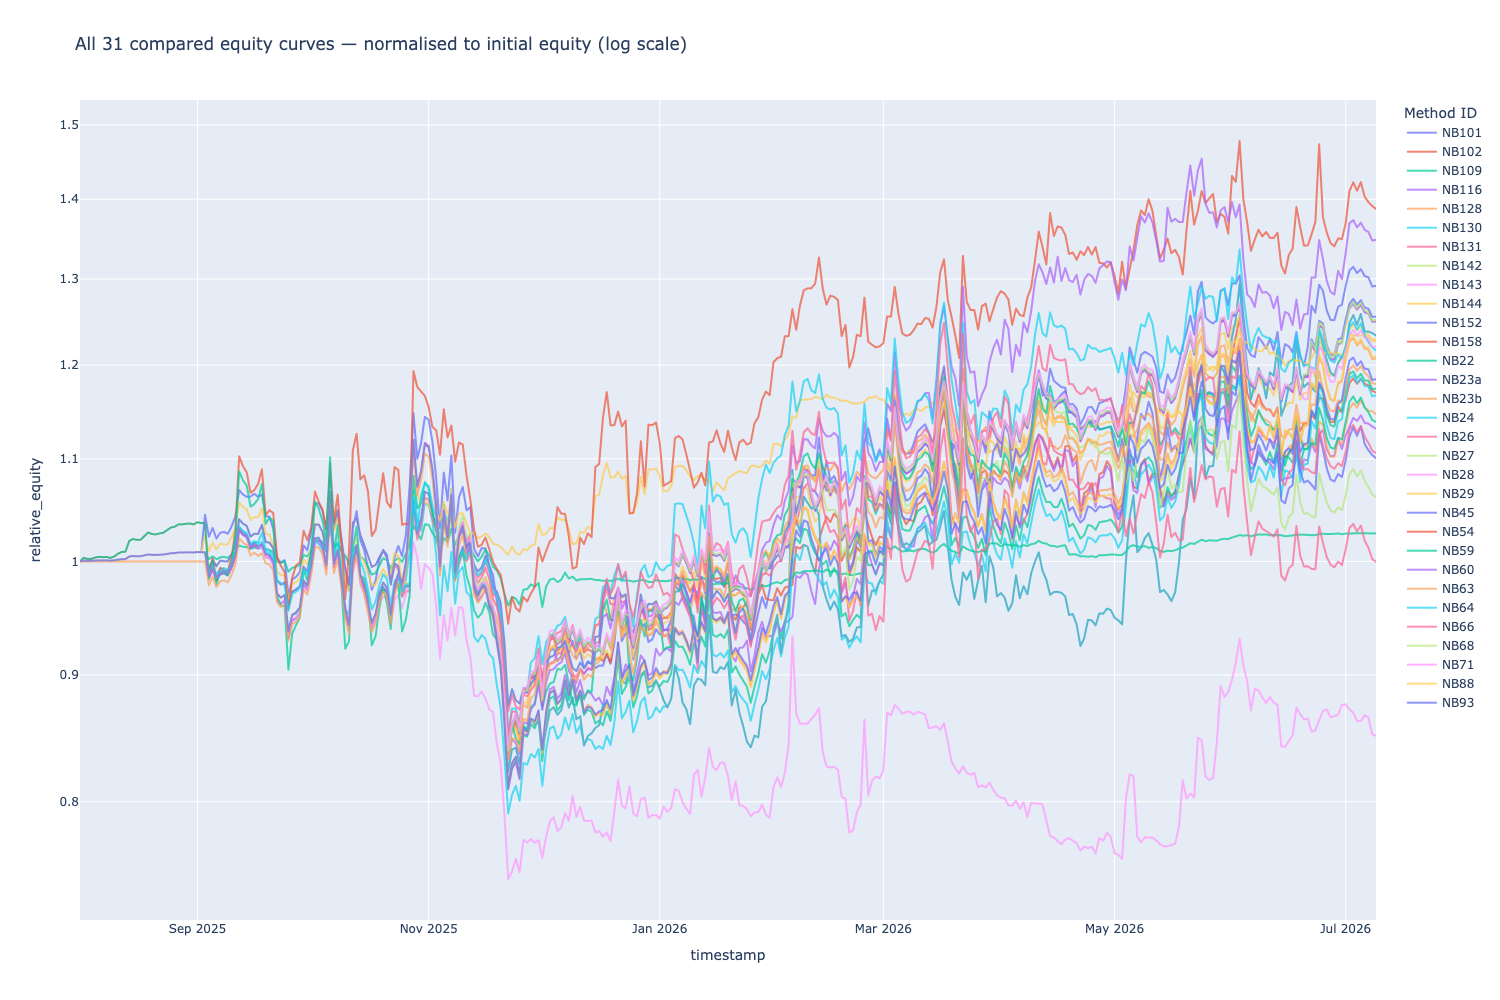

In [11]:
all_curves = []
for source_id, curve in sorted(trial_equity_curves.items()):
    curve_df = curve.rename('equity').rename_axis('timestamp').reset_index()
    curve_df['ID'] = source_id
    curve_df['relative_equity'] = curve_df['equity'] / curve_df['equity'].iloc[0]
    all_curves.append(curve_df)

assert len(all_curves) == 31
all_equity_plot_df = pd.concat(all_curves, ignore_index=True)
fig = px.line(
    all_equity_plot_df,
    x='timestamp',
    y='relative_equity',
    color='ID',
    log_y=True,
    title='All 31 compared equity curves — normalised to initial equity (log scale)',
    hover_data={'equity': ':,.2f', 'relative_equity': ':.2f'},
)
fig.update_traces(opacity=0.72)
fig.update_layout(legend_title_text='Method ID')
fig.show()

# Use complete 90-observation windows on the daily backtest return series.
rolling_sharpe_window_days = 90
annualisation_factor = math.sqrt(365.0)
rolling_sharpe_frames = []
rolling_sharpe_metric_rows = []

for source_id, curve in sorted(trial_equity_curves.items()):
    daily_returns = calculate_returns(curve).resample('1D').sum(min_count=1).fillna(0.0)
    rolling_mean = daily_returns.rolling(rolling_sharpe_window_days, min_periods=rolling_sharpe_window_days).mean()
    rolling_volatility = daily_returns.rolling(rolling_sharpe_window_days, min_periods=rolling_sharpe_window_days).std()
    rolling_sharpe = annualisation_factor * rolling_mean / rolling_volatility.replace(0.0, float('nan'))
    
    rolling_sharpe_metric_rows.append({
        'ID': source_id,
        '90d rolling Sharpe min': float(rolling_sharpe.min()),
        '90d rolling Sharpe mean': float(rolling_sharpe.mean()),
        '90d rolling Sharpe max': float(rolling_sharpe.max()),
    })
    
    rolling_sharpe_frames.append(
        rolling_sharpe.rename('rolling_sharpe').rename_axis('timestamp').reset_index().assign(ID=source_id)
    )

rolling_sharpe_metrics_df = pd.DataFrame(rolling_sharpe_metric_rows)
all_rolling_sharpe_plot_df = pd.concat(rolling_sharpe_frames, ignore_index=True).dropna(subset=['rolling_sharpe'])


## Performance metrics and rolling Sharpe comparison

Compare each method using full-period and clean extension-holdout figures. The holdout begins after the common historical research cut-off and is the primary comparison; all figures derive from the shared-universe runs above. The cluster maps use deterministic three-cluster K-means on the displayed full-period metric pair.

,ID,Method,Family,Provenance,Full CAGR,Full Sharpe,Full Sortino,Full Calmar,Full Max DD,90d rolling Sharpe min,90d rolling Sharpe mean,90d rolling Sharpe max,Holdout CAGR,Holdout Sharpe,Holdout Sortino,Holdout Calmar,Holdout Max DD
20,NB54,PSR concentration,combined,historical_overlap,41.82%,0.99,1.62,2.00,-20.91%,-0.32,1.15,2.85,38.83%,0.97,1.60,3.36,-11.57%
15,NB60,Bayesian credibility weighting,weight,historical_overlap,37.55%,0.98,1.53,1.47,-25.62%,-1.40,1.20,3.61,57.65%,1.25,2.06,3.92,-14.70%
0,NB101,Age ramp with trend overlay,combined,historical_overlap,31.42%,0.92,1.42,1.18,-26.61%,-1.69,1.02,2.90,49.84%,1.49,2.39,6.16,-8.09%
4,NB152,Equal-weight recycle with minimum hold,combined,historical_overlap,27.46%,0.85,1.29,1.09,-25.11%,-1.37,1.00,3.04,45.78%,1.35,2.22,5.43,-8.43%
5,NB142,Equal-weight recycle,allocator,historical_overlap,27.05%,0.84,1.28,1.08,-25.11%,-1.37,1.00,3.04,44.44%,1.33,2.17,5.27,-8.43%
9,NB68,Bayesian gate with equal weight,selector,historical_overlap,27.01%,0.84,1.28,1.08,-25.02%,-1.36,1.00,3.07,43.16%,1.30,2.12,5.12,-8.44%
7,NB131,Age-ramp selection with equal deployment,combined,historical_overlap,26.86%,0.83,1.27,1.07,-25.16%,-1.33,1.00,3.05,43.83%,1.31,2.15,5.20,-8.43%
8,NB23a,Equal weight,weight,historical_overlap,26.86%,0.83,1.27,1.07,-25.16%,-1.33,1.00,3.05,43.83%,1.31,2.15,5.20,-8.43%
1,NB158,Waterfall release candidate,combined,historical_overlap,25.11%,0.72,1.13,0.95,-26.48%,-2.23,0.52,2.60,73.72%,1.48,2.36,6.27,-11.76%
2,NB143,Capped survivor-first waterfall,allocator,historical_overlap,25.11%,0.72,1.13,0.95,-26.48%,-2.23,0.52,2.60,73.72%,1.48,2.36,6.27,-11.76%


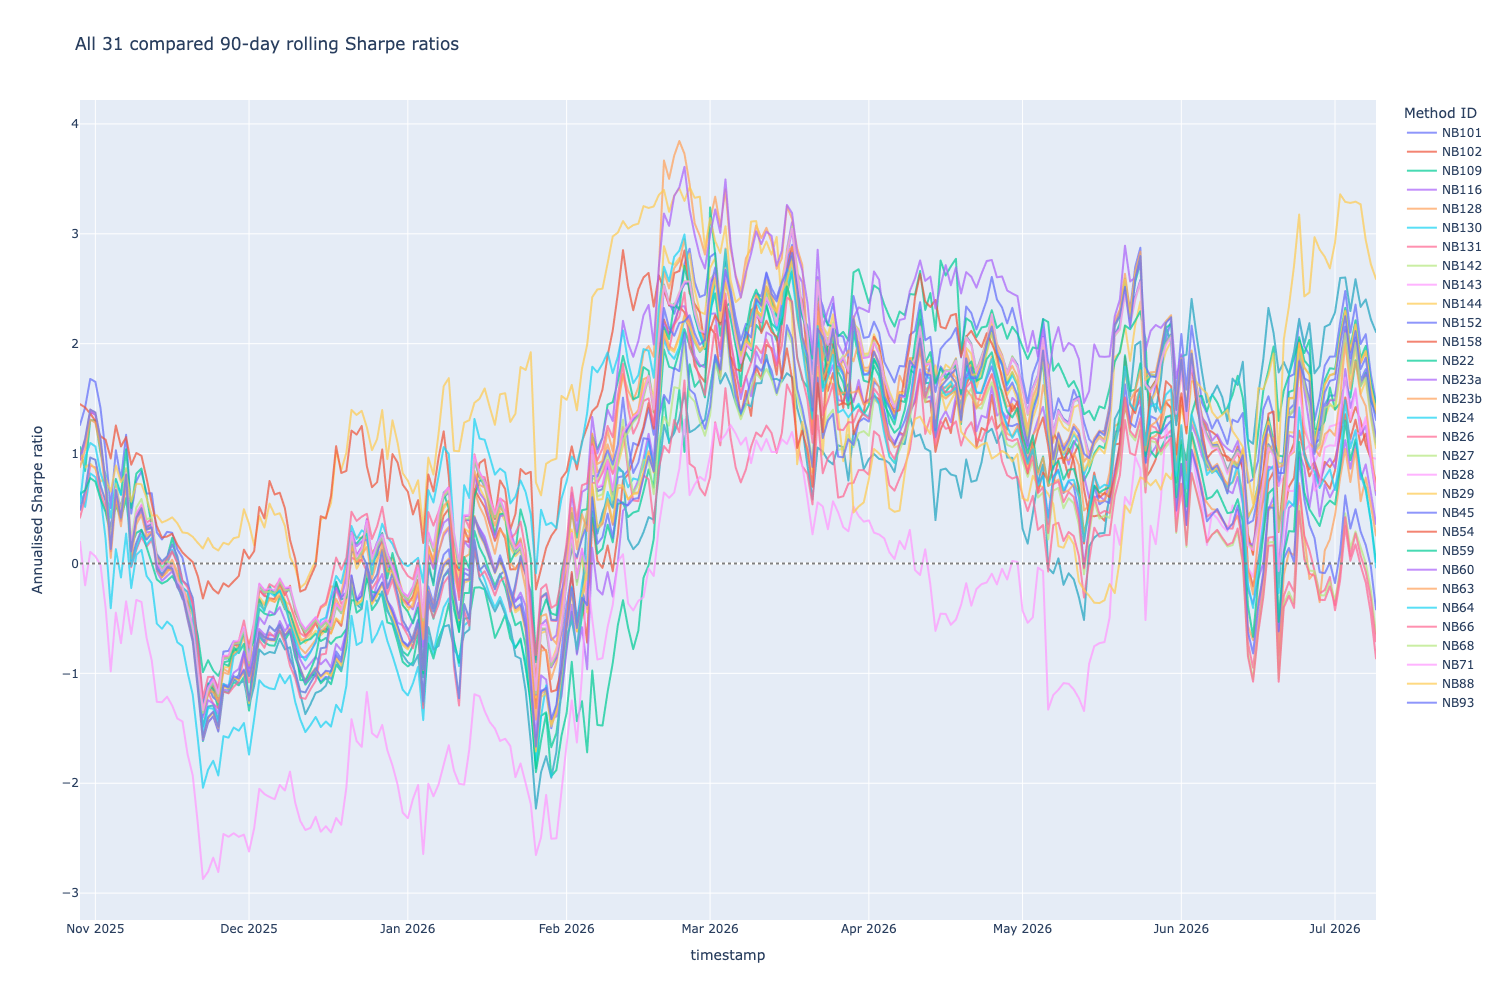

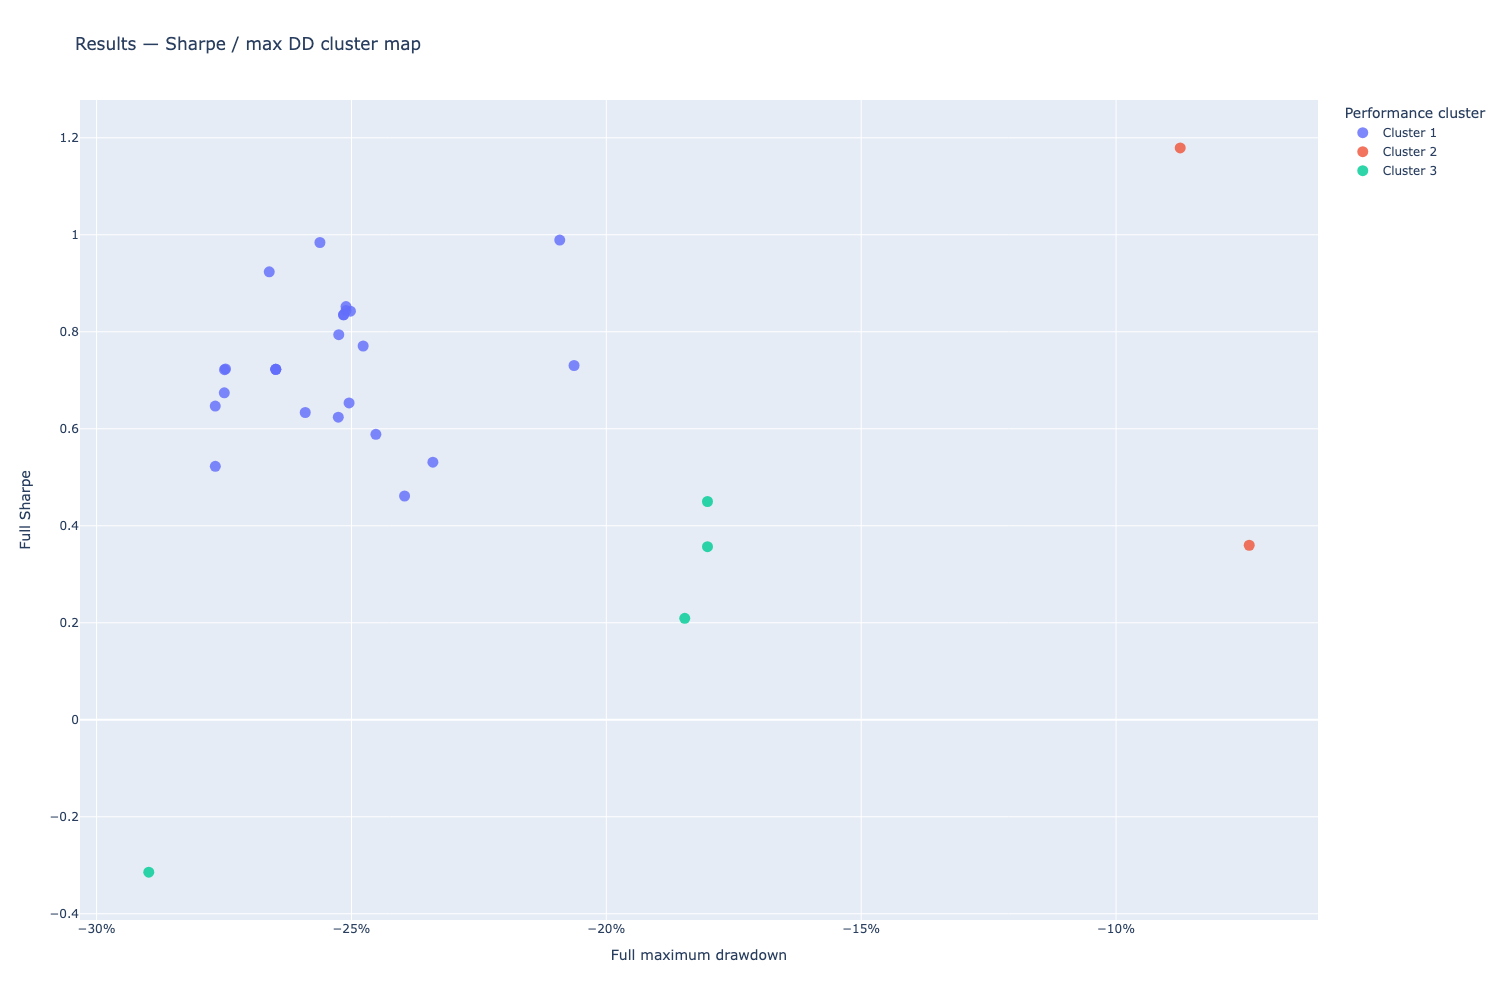

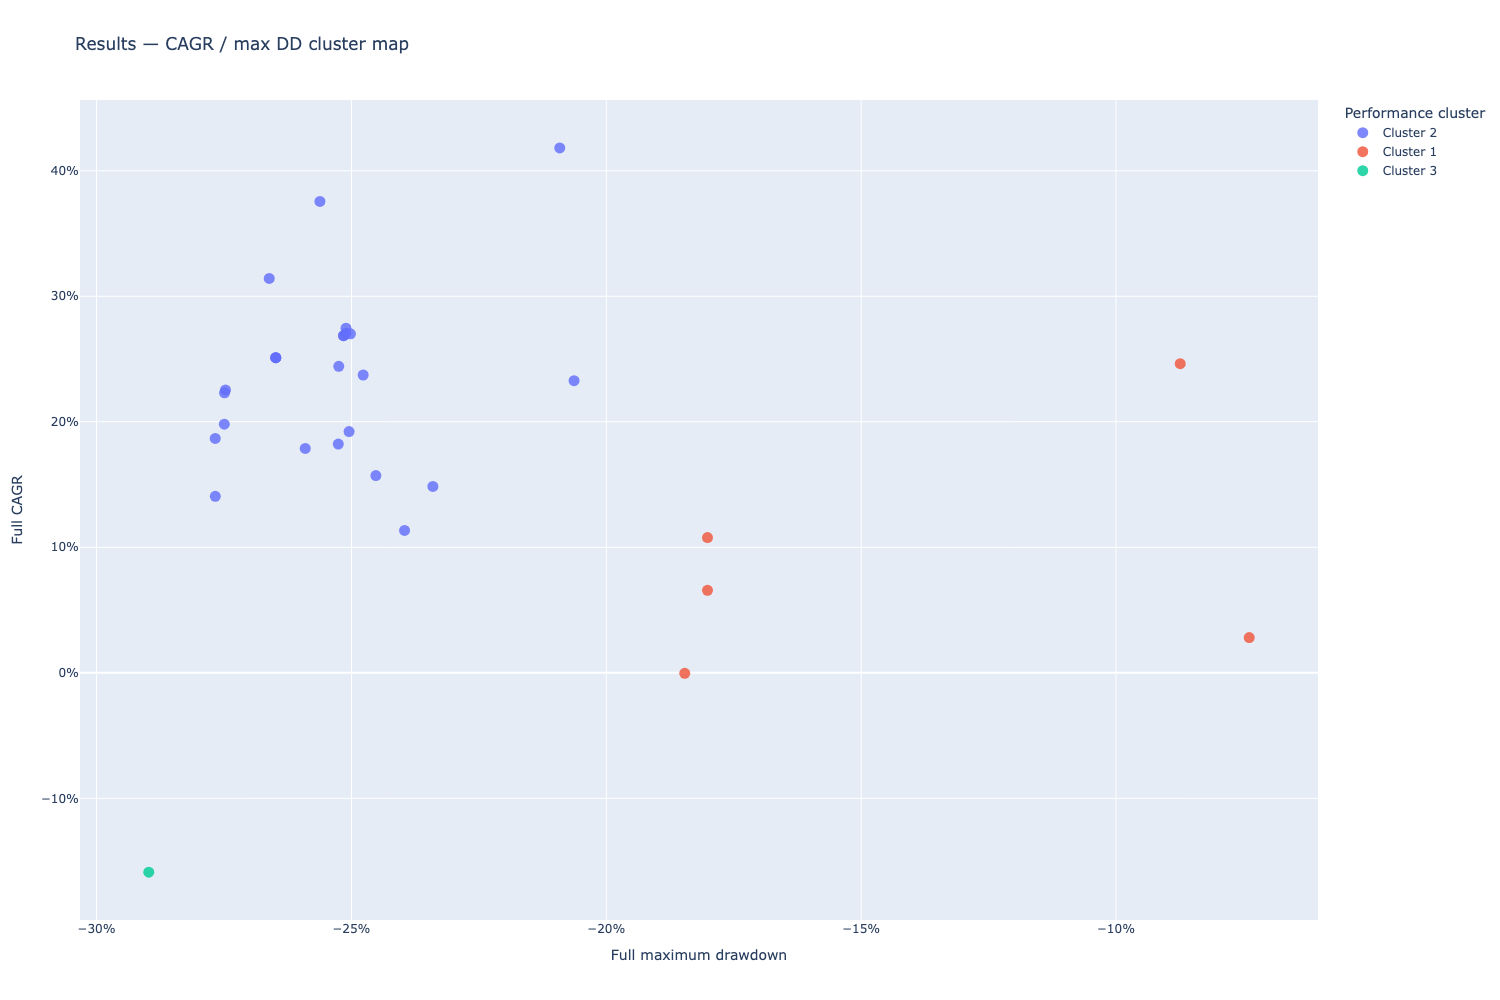

In [12]:
performance_columns = [
    'ID', 'Method', 'Family', 'Provenance',
    'Full CAGR', 'Full Sharpe', 'Full Sortino', 'Full Calmar', 'Full Max DD',
    '90d rolling Sharpe min', '90d rolling Sharpe mean', '90d rolling Sharpe max',
    'Holdout CAGR', 'Holdout Sharpe', 'Holdout Sortino', 'Holdout Calmar', 'Holdout Max DD',
]
performance_metrics_df = successful_df.merge(rolling_sharpe_metrics_df, on='ID', how='left', validate='one_to_one').loc[:, performance_columns].sort_values(
    ['Full CAGR', 'ID'],
    ascending=[False, True],
)
percentage_columns = ['Full CAGR', 'Full Max DD', 'Holdout CAGR', 'Holdout Max DD']
ratio_columns = ['Full Sharpe', 'Full Sortino', 'Full Calmar', '90d rolling Sharpe min', '90d rolling Sharpe mean', '90d rolling Sharpe max', 'Holdout Sharpe', 'Holdout Sortino', 'Holdout Calmar']
display(
    performance_metrics_df.style
    .format({column: '{:.2%}' for column in percentage_columns} | {column: '{:.2f}' for column in ratio_columns})
    .set_caption('All successful methods — full-period and clean extension holdout performance metrics')
)

fig = px.line(
    all_rolling_sharpe_plot_df,
    x='timestamp',
    y='rolling_sharpe',
    color='ID',
    title='All 31 compared 90-day rolling Sharpe ratios',
)
fig.add_hline(y=0.0, line_dash='dot', line_color='grey')
fig.update_traces(opacity=0.72)
fig.update_layout(legend_title_text='Method ID', yaxis_title='Annualised Sharpe ratio')
fig.show()

def display_performance_cluster_maps(metrics_df: pd.DataFrame, section_name: str) -> pd.DataFrame:
    """Cluster and plot the full-period risk/return metric pairs for one result section."""
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler

    def create_map(y_column: str, y_title: str) -> pd.DataFrame:
        map_df = metrics_df[['ID', 'Method', 'Family', 'Full Max DD', y_column]].dropna().copy()
        feature_columns = ['Full Max DD', y_column]
        cluster_count = min(3, len(map_df[feature_columns].drop_duplicates()))
        scaled_features = StandardScaler().fit_transform(map_df[feature_columns])
        labels = KMeans(n_clusters=cluster_count, n_init=20, random_state=42).fit_predict(scaled_features)
        map_df['Cluster'] = pd.Categorical([f'Cluster {label + 1}' for label in labels])

        fig = px.scatter(
            map_df,
            x='Full Max DD',
            y=y_column,
            color='Cluster',
            hover_name='ID',
            hover_data={'Method': True, 'Family': True, 'Full Max DD': ':.2%', y_column: ':.2%' if y_column == 'Full CAGR' else ':.2f'},
            title=f'{section_name} — {y_title} / max DD cluster map',
        )
        fig.update_traces(marker={'size': 11, 'opacity': 0.82})
        fig.update_layout(legend_title_text='Performance cluster', xaxis_title='Full maximum drawdown')
        fig.update_xaxes(tickformat='.0%')
        if y_column == 'Full CAGR':
            fig.update_yaxes(tickformat='.0%')
        fig.show()
        return map_df

    sharpe_clusters = create_map('Full Sharpe', 'Sharpe')
    cagr_clusters = create_map('Full CAGR', 'CAGR')
    return sharpe_clusters.merge(cagr_clusters[['ID', 'Cluster']], on='ID', suffixes=(' Sharpe / max DD', ' CAGR / max DD'))

raw_performance_clusters_df = display_performance_cluster_maps(performance_metrics_df, 'Results')


# Results without outliers

This robustness view neutralises only each method's largest 5% of strictly profitable daily portfolio returns to 0%. Negative returns remain unchanged, preserving adverse outcomes and the original calendar length. It is an ex-post return-series sensitivity analysis: selections, weights, trades, and trading costs are identical to the unfiltered backtests.

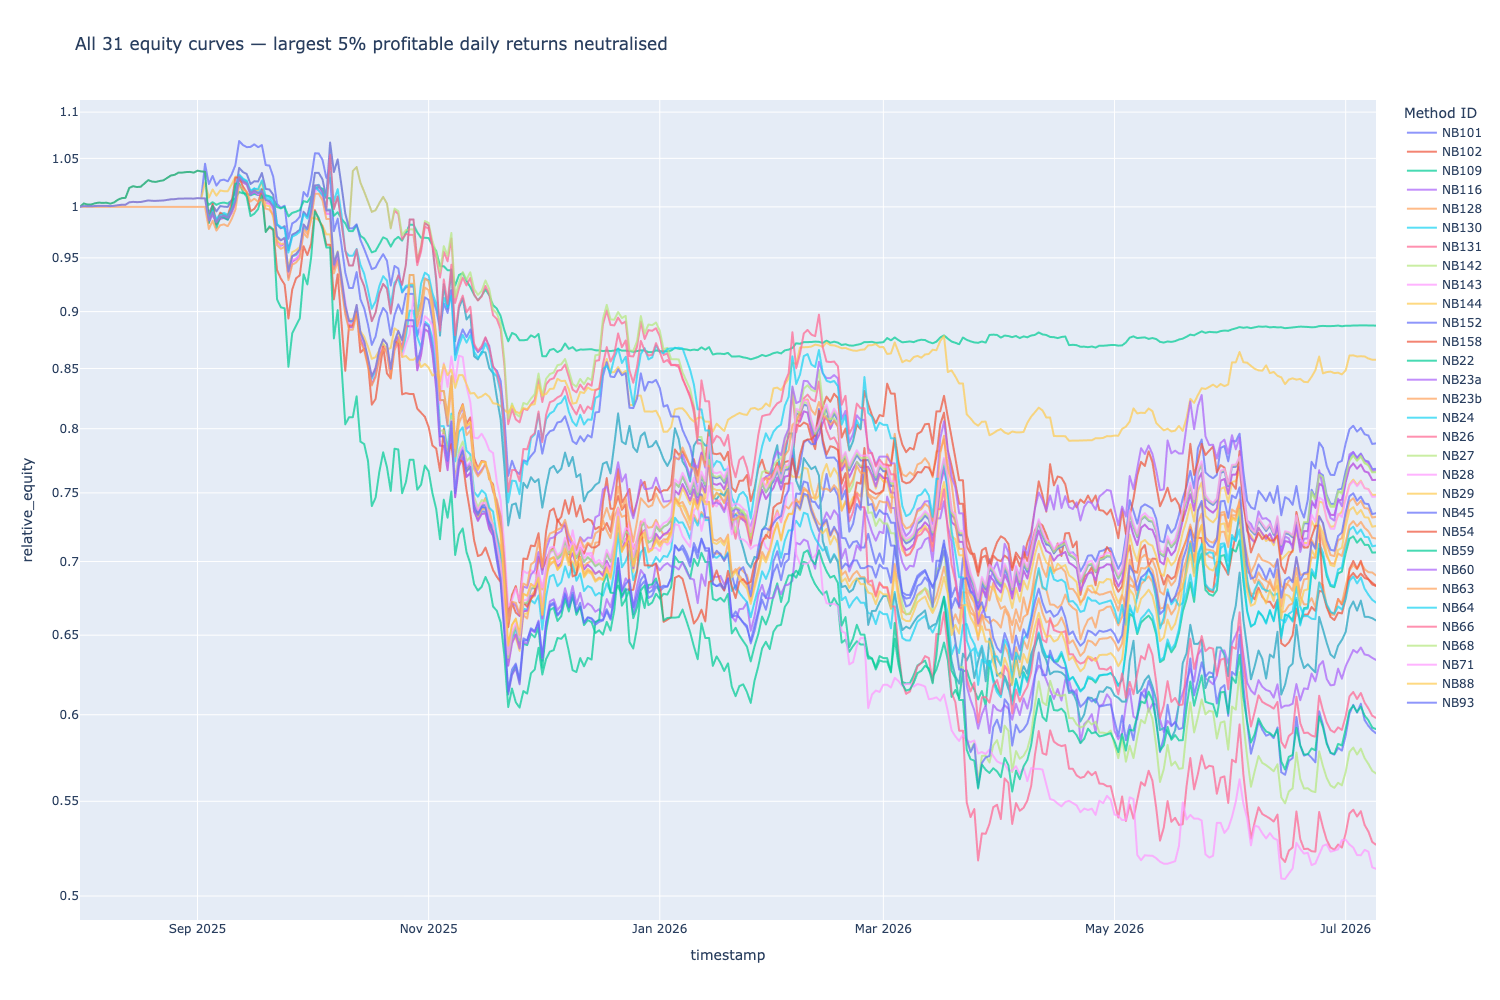

,ID,Method,Family,Provenance,Removed profitable days,Profitable-return cutoff,Full CAGR,Full Sharpe,Full Sortino,Full Calmar,Full Max DD,90d rolling Sharpe min,90d rolling Sharpe mean,90d rolling Sharpe max,Holdout CAGR,Holdout Sharpe,Holdout Sortino,Holdout Calmar,Holdout Max DD
12,NB22,Inverse-volatility weighting,weight,historical_overlap,9,1.08%,-11.97%,-1.78,-2.10,-0.75,-15.90%,-5.77,-1.26,2.04,4.44%,1.27,1.96,2.93,-1.51%
19,NB29,Dynamic diversified waterfall,combined,historical_overlap,10,2.27%,-15.13%,-0.99,-1.26,-0.65,-23.33%,-4.56,-1.12,2.73,-0.61%,0.03,0.03,-0.06,-10.01%
0,NB101,Age ramp with trend overlay,combined,historical_overlap,9,4.22%,-22.42%,-0.63,-0.84,-0.53,-42.68%,-5.10,-0.81,2.48,49.84%,1.49,2.39,6.16,-8.09%
10,NB152,Equal-weight recycle with minimum hold,combined,historical_overlap,9,4.52%,-24.51%,-0.74,-0.98,-0.64,-38.42%,-4.79,-0.90,2.52,17.38%,0.70,1.05,1.32,-13.17%
23,NB60,Bayesian credibility weighting,weight,historical_overlap,9,5.13%,-24.60%,-0.63,-0.85,-0.68,-36.19%,-4.12,-0.70,2.87,12.19%,0.49,0.71,0.66,-18.41%
7,NB142,Equal-weight recycle,allocator,historical_overlap,9,4.52%,-24.75%,-0.75,-0.99,-0.64,-38.42%,-4.79,-0.91,2.52,16.31%,0.67,1.00,1.24,-13.17%
27,NB68,Bayesian gate with equal weight,selector,historical_overlap,9,4.53%,-24.78%,-0.75,-0.99,-0.65,-38.35%,-4.79,-0.90,2.53,15.28%,0.64,0.95,1.16,-13.17%
6,NB131,Age-ramp selection with equal deployment,combined,historical_overlap,9,4.52%,-25.40%,-0.77,-1.01,-0.66,-38.75%,-4.76,-0.91,2.52,15.82%,0.65,0.98,1.20,-13.17%
13,NB23a,Equal weight,weight,historical_overlap,9,4.52%,-25.40%,-0.77,-1.01,-0.66,-38.75%,-4.76,-0.91,2.52,15.82%,0.65,0.98,1.20,-13.17%
9,NB144,Capacity-aware equal weight,allocator,historical_overlap,9,4.33%,-26.59%,-0.86,-1.13,-0.69,-38.54%,-4.75,-0.99,2.31,11.52%,0.53,0.79,0.92,-12.54%


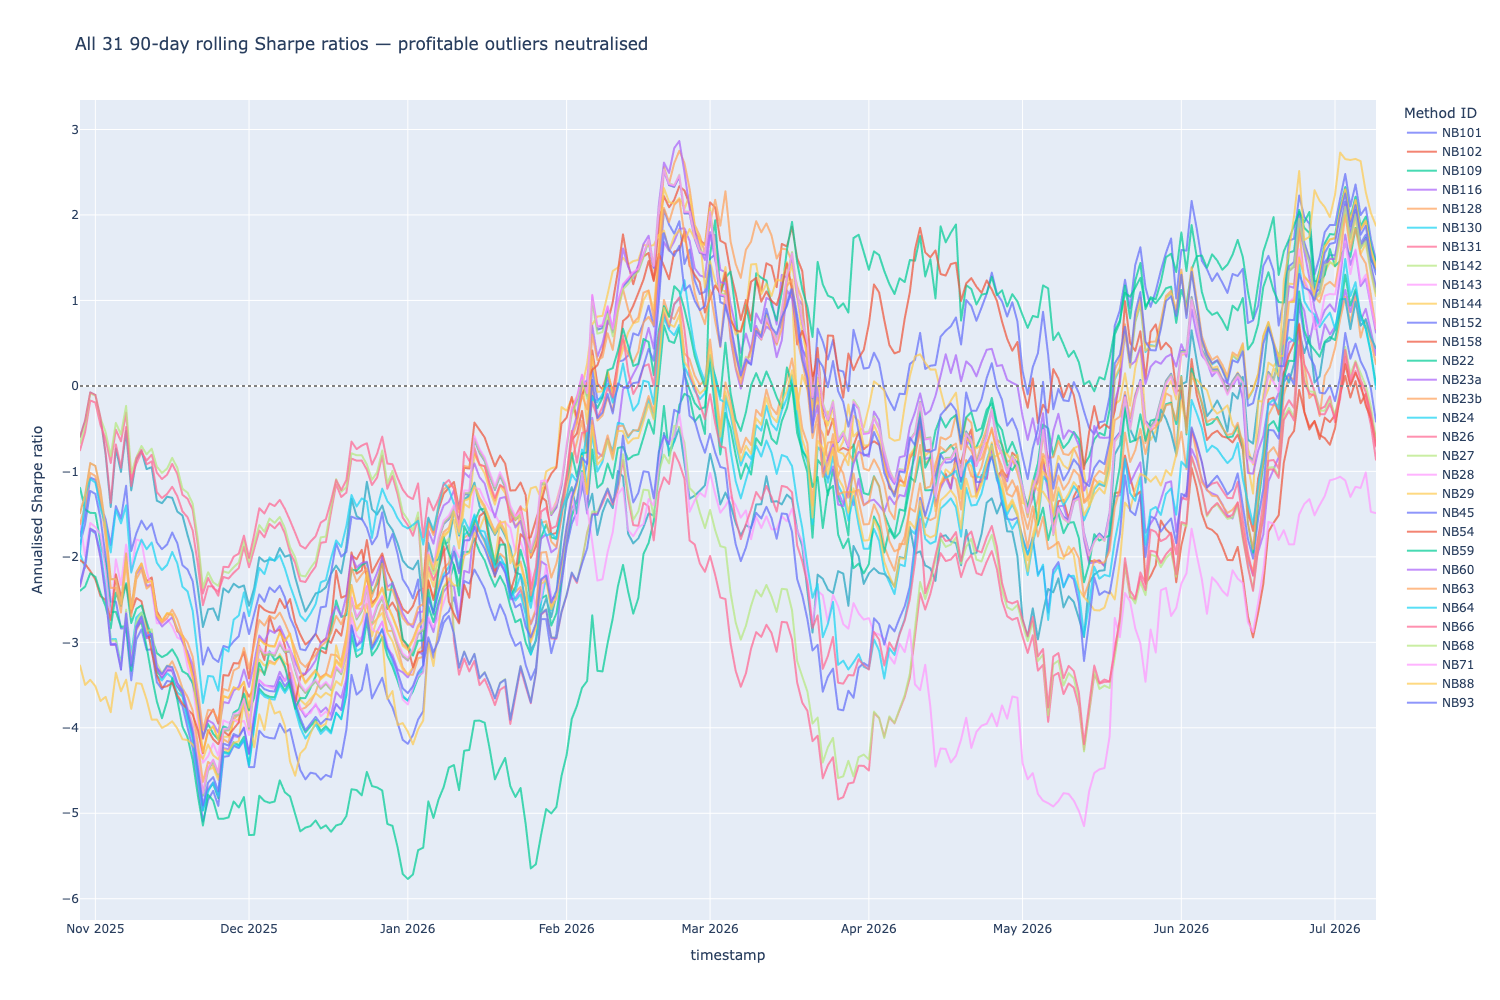

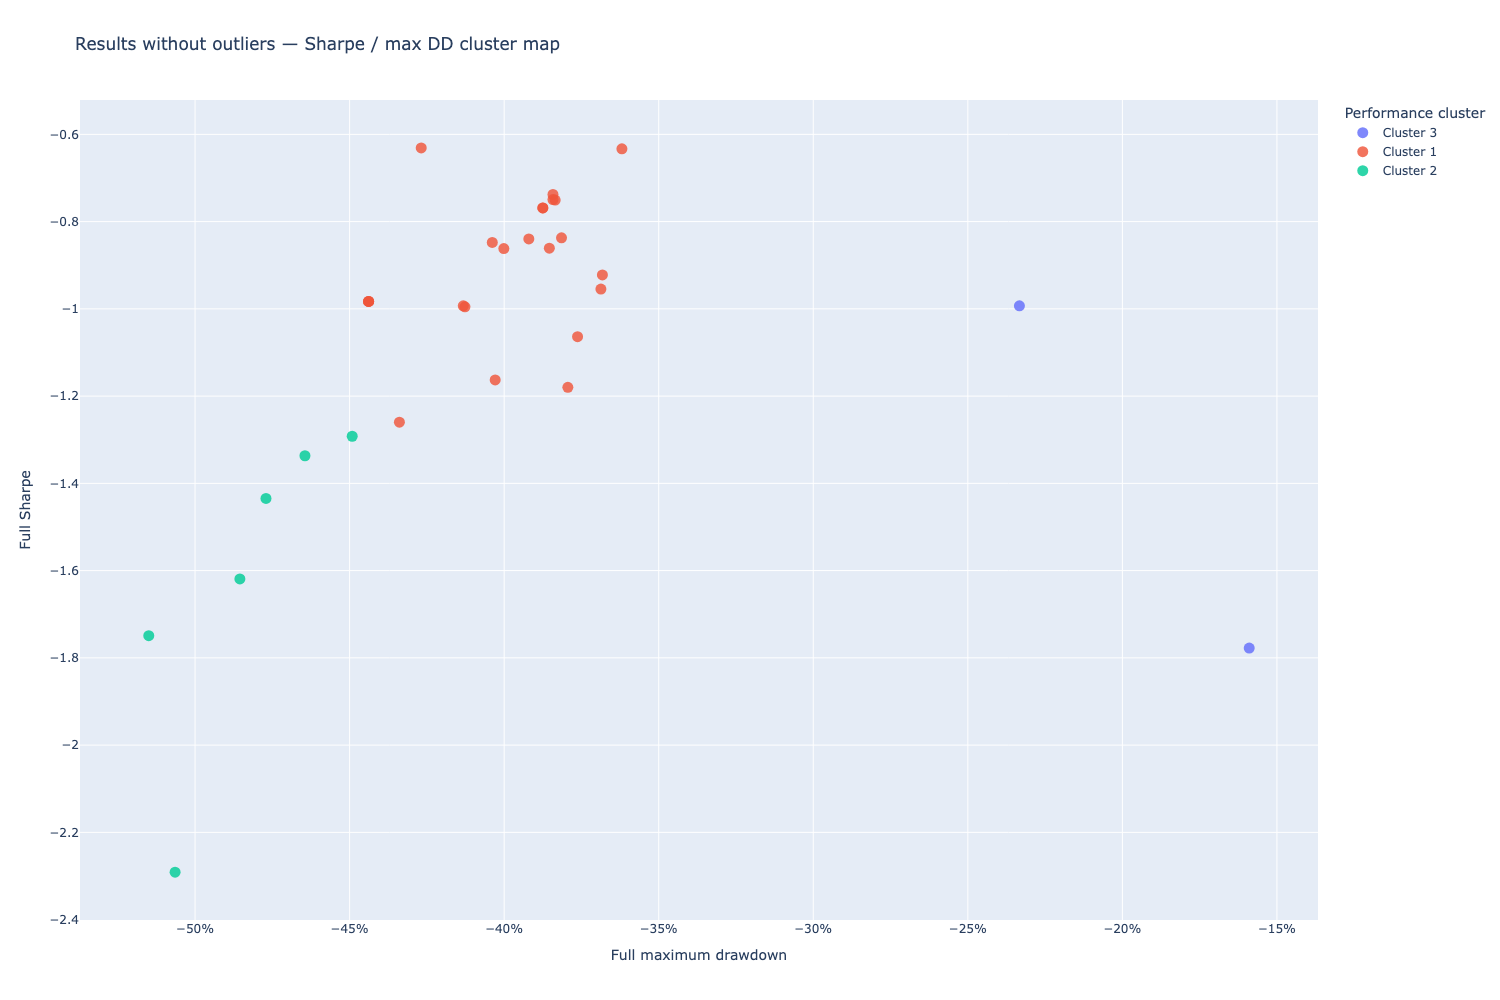

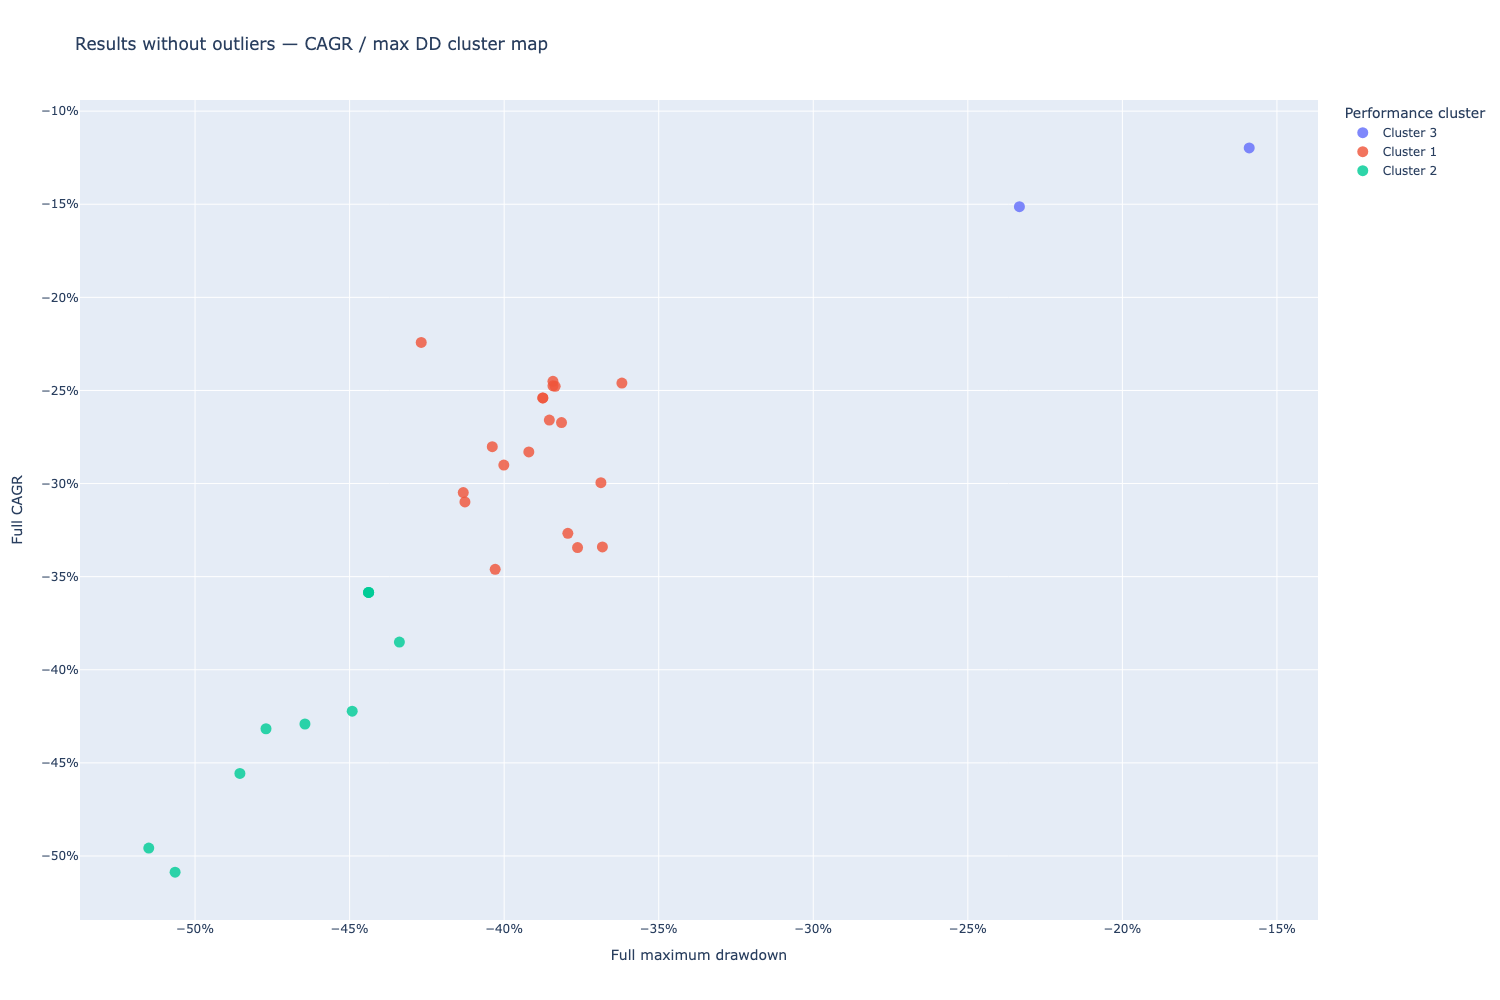

In [13]:
profitable_outlier_quantile = 0.95
outlier_equity_curves = {}
outlier_return_series = {}
outlier_rows = []
method_metadata = successful_df.set_index('ID')

for source_id, raw_curve in sorted(trial_equity_curves.items()):
    daily_returns = calculate_returns(raw_curve).resample('1D').sum(min_count=1).fillna(0.0)
    profitable_returns = daily_returns[daily_returns > 0.0]
    profitable_outlier_cutoff = profitable_returns.quantile(profitable_outlier_quantile) if len(profitable_returns) else float('inf')
    profitable_outlier_mask = (daily_returns > 0.0) & (daily_returns > profitable_outlier_cutoff)
    returns_without_outliers = daily_returns.mask(profitable_outlier_mask, 0.0)

    equity_without_outliers = raw_curve.iloc[0] * (1.0 + returns_without_outliers).cumprod()
    equity_without_outliers.name = raw_curve.name
    equity_without_outliers.attrs = raw_curve.attrs.copy()
    outlier_equity_curves[source_id] = equity_without_outliers
    outlier_return_series[source_id] = returns_without_outliers

    row = {
        'ID': source_id,
        **method_metadata.loc[source_id, ['Method', 'Family', 'Provenance']].to_dict(),
        'Removed profitable days': int(profitable_outlier_mask.sum()),
        'Profitable-return cutoff': float(profitable_outlier_cutoff),
    }
    row.update(_metric_block(returns_without_outliers, 'Full'))
    row.update(_metric_block(returns_without_outliers.loc[returns_without_outliers.index >= pd.Timestamp('2026-03-12')], 'Holdout'))
    outlier_rows.append(row)

assert len(outlier_equity_curves) == len(trial_equity_curves) == 31

outlier_curve_frames = []
for source_id, curve in sorted(outlier_equity_curves.items()):
    curve_df = curve.rename('equity').rename_axis('timestamp').reset_index()
    curve_df['ID'] = source_id
    curve_df['relative_equity'] = curve_df['equity'] / curve_df['equity'].iloc[0]
    outlier_curve_frames.append(curve_df)

outlier_equity_plot_df = pd.concat(outlier_curve_frames, ignore_index=True)
fig = px.line(
    outlier_equity_plot_df,
    x='timestamp',
    y='relative_equity',
    color='ID',
    log_y=True,
    title='All 31 equity curves — largest 5% profitable daily returns neutralised',
    hover_data={'equity': ':,.2f', 'relative_equity': ':.2f'},
)
fig.update_traces(opacity=0.72)
fig.update_layout(legend_title_text='Method ID')
fig.show()

outlier_rolling_sharpe_frames = []
outlier_rolling_sharpe_metric_rows = []
for source_id, daily_returns in sorted(outlier_return_series.items()):
    rolling_mean = daily_returns.rolling(rolling_sharpe_window_days, min_periods=rolling_sharpe_window_days).mean()
    rolling_volatility = daily_returns.rolling(rolling_sharpe_window_days, min_periods=rolling_sharpe_window_days).std()
    rolling_sharpe = annualisation_factor * rolling_mean / rolling_volatility.replace(0.0, float('nan'))
    outlier_rolling_sharpe_metric_rows.append({
        'ID': source_id,
        '90d rolling Sharpe min': float(rolling_sharpe.min()),
        '90d rolling Sharpe mean': float(rolling_sharpe.mean()),
        '90d rolling Sharpe max': float(rolling_sharpe.max()),
    })
    outlier_rolling_sharpe_frames.append(
        rolling_sharpe.rename('rolling_sharpe').rename_axis('timestamp').reset_index().assign(ID=source_id)
    )

outlier_rolling_sharpe_metrics_df = pd.DataFrame(outlier_rolling_sharpe_metric_rows)
outlier_performance_columns = [
    'ID', 'Method', 'Family', 'Provenance', 'Removed profitable days', 'Profitable-return cutoff',
    'Full CAGR', 'Full Sharpe', 'Full Sortino', 'Full Calmar', 'Full Max DD',
    '90d rolling Sharpe min', '90d rolling Sharpe mean', '90d rolling Sharpe max',
    'Holdout CAGR', 'Holdout Sharpe', 'Holdout Sortino', 'Holdout Calmar', 'Holdout Max DD',
]
outlier_performance_metrics_df = pd.DataFrame(outlier_rows).merge(
    outlier_rolling_sharpe_metrics_df,
    on='ID',
    how='left',
    validate='one_to_one',
).loc[:, outlier_performance_columns].sort_values(['Full CAGR', 'ID'], ascending=[False, True])
outlier_percentage_columns = ['Profitable-return cutoff', 'Full CAGR', 'Full Max DD', 'Holdout CAGR', 'Holdout Max DD']
outlier_ratio_columns = [
    'Full Sharpe', 'Full Sortino', 'Full Calmar',
    '90d rolling Sharpe min', '90d rolling Sharpe mean', '90d rolling Sharpe max',
    'Holdout Sharpe', 'Holdout Sortino', 'Holdout Calmar',
]
display(
    outlier_performance_metrics_df.style
    .format({column: '{:.2%}' for column in outlier_percentage_columns} | {column: '{:.2f}' for column in outlier_ratio_columns})
    .set_caption('All successful methods — largest 5% of profitable daily returns neutralised; losses retained')
)

outlier_rolling_sharpe_plot_df = pd.concat(outlier_rolling_sharpe_frames, ignore_index=True).dropna(subset=['rolling_sharpe'])
fig = px.line(
    outlier_rolling_sharpe_plot_df,
    x='timestamp',
    y='rolling_sharpe',
    color='ID',
    title='All 31 90-day rolling Sharpe ratios — profitable outliers neutralised',
)
fig.add_hline(y=0.0, line_dash='dot', line_color='grey')
fig.update_traces(opacity=0.72)
fig.update_layout(legend_title_text='Method ID', yaxis_title='Annualised Sharpe ratio')
fig.show()

outlier_performance_clusters_df = display_performance_cluster_maps(
    outlier_performance_metrics_df,
    'Results without outliers',
)
